In [1]:
import os
import random
import math
import numpy as np
import pandas as pd
import nibabel as nib
import tensorflow as tf

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, Callback
from tensorflow.keras.optimizers.schedules import CosineDecay

from scipy.ndimage import binary_closing, binary_fill_holes
from sklearn.model_selection import train_test_split

# SAFETY NET 1: Mixed precision for RAM, but requires strict float32 casting in losses
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Multi-GPU Strategy
strategy = tf.distribute.MirroredStrategy()
print("GPUs available:", strategy.num_replicas_in_sync)

2026-03-08 08:49:43.961445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772959784.141088      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772959784.191329      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772959784.626144      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772959784.626187      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772959784.626189      24 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs available: 2


I0000 00:00:1772959807.631935      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772959807.637695      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
print(os.listdir("/kaggle/input/datasets/tarun050/weights"))

['training_log.csv', 'best_model.weights.h5', 'latest_model.weights.h5']


In [3]:
import os
import shutil

# 1. PASTE YOUR COPIED PATH RIGHT HERE:
# It should look something like: "/kaggle/input/brats-checkpoints-epoch30"
UPLOADED_DATASET_PATH = "/kaggle/input/datasets/tarun050/weights" 

# 2. Destination (where Keras expects them)
WORKING_DIR = "/kaggle/working"

files_to_resume = [
    "latest_model.weights.h5",
    "best_model.weights.h5",
    "training_log.csv"
]

print("Copying resume files to the working directory...")

for filename in files_to_resume:
    src_path = os.path.join(UPLOADED_DATASET_PATH, filename)
    dst_path = os.path.join(WORKING_DIR, filename)
    
    # Check if the file exists in your uploaded dataset
    if os.path.exists(src_path):
        # Only copy if we haven't already copied it today
        if not os.path.exists(dst_path):
            shutil.copy(src_path, dst_path)
            print(f"✅ Successfully copied: {filename}")
        else:
            print(f"⏭️ Already exists in working dir: {filename}")
    else:
        print(f"❌ WARNING: Could not find {filename} in your uploaded folder!")

Copying resume files to the working directory...
✅ Successfully copied: latest_model.weights.h5
✅ Successfully copied: best_model.weights.h5
✅ Successfully copied: training_log.csv


In [4]:
WORK_DIR = "/kaggle/working/brats2021"
os.makedirs(WORK_DIR, exist_ok=True)

# Un-comment this block if you still need to extract the dataset:
import tarfile
main_tar = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"
with tarfile.open(main_tar, 'r') as tar:
    tar.extractall(path=WORK_DIR)
print("Extraction complete!")

PATCH_SIZE = 128
STRIDE = 64
BATCH_SIZE = 2  
EPOCHS = 50   # Set exactly to 50 as requested
NUM_CLASSES = 4

LATEST_MODEL_PATH = "/kaggle/working/latest_model.weights.h5"
BEST_MODEL_PATH = "/kaggle/working/best_model.weights.h5"
LOG_PATH = "/kaggle/working/training_log.csv"

required_suffixes = ["_t1.nii.gz", "_t1ce.nii.gz", "_t2.nii.gz", "_flair.nii.gz", "_seg.nii.gz"]

/tmp/ipykernel_24/3811280840.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=WORK_DIR)


Extraction complete!


In [5]:
valid_cases = []
if os.path.exists(WORK_DIR):
    for patient in os.listdir(WORK_DIR):
        patient_path = os.path.join(WORK_DIR, patient)
        if not os.path.isdir(patient_path): continue
        files = os.listdir(patient_path)
        if all(any(f.endswith(suffix) for f in files) for suffix in required_suffixes):
            valid_cases.append(patient_path)

patients = sorted(valid_cases)
subset = random.sample(patients, min(600, len(patients))) if patients else []

if subset:
    train_ids, val_ids = train_test_split(subset, train_size=500, test_size=100, random_state=42)
    print(f"Train size: {len(train_ids)} | Val size: {len(val_ids)}")
else:
    print("No patient data found. Please check extraction path.")

Train size: 500 | Val size: 100


In [6]:
def load_patient(case_path):
    pid = os.path.basename(case_path)
    flair = nib.load(os.path.join(case_path, f"{pid}_flair.nii.gz")).get_fdata()
    t1 = nib.load(os.path.join(case_path, f"{pid}_t1.nii.gz")).get_fdata()
    t1ce = nib.load(os.path.join(case_path, f"{pid}_t1ce.nii.gz")).get_fdata()
    t2 = nib.load(os.path.join(case_path, f"{pid}_t2.nii.gz")).get_fdata()
    seg = nib.load(os.path.join(case_path, f"{pid}_seg.nii.gz")).get_fdata()

    seg[seg == 4] = 3 
    return np.stack([flair, t1, t1ce, t2], axis=-1), seg

def crop_brain_roi(volume, mask):
    brain = volume[..., 0] > 0
    coords = np.argwhere(brain)
    if len(coords) == 0: return volume, mask
    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0)
    return volume[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1], mask[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1]

def normalize_mri(volume):
    brain_mask = volume > 0
    normalized = np.zeros_like(volume, dtype=np.float32)
    for i in range(volume.shape[-1]):
        channel = volume[..., i]
        mask = brain_mask[..., i]
        if mask.any():
            mean, std = channel[mask].mean(), channel[mask].std()
            # SAFETY NET 2: + 1e-8 prevents ZeroDivisionError in blank MRI channels
            normalized[..., i] = (channel - mean) / (std + 1e-8) 
    return normalized

def one_hot(mask):
    out = np.zeros(mask.shape + (NUM_CLASSES,), dtype=np.float32)
    for i in range(NUM_CLASSES): out[..., i] = (mask == i).astype(np.float32)
    return out

In [7]:
def pad_for_training(volume, mask, patch_size):
    z, y, x = volume.shape[:3]
    pad_z, pad_y, pad_x = max(patch_size - z, 0), max(patch_size - y, 0), max(patch_size - x, 0)
    pad_before = (pad_z // 2, pad_y // 2, pad_x // 2)
    pad_after = (pad_z - pad_before[0], pad_y - pad_before[1], pad_x - pad_before[2])
    
    volume = np.pad(volume, ((pad_before[0], pad_after[0]), (pad_before[1], pad_after[1]), (pad_before[2], pad_after[2]), (0,0)), mode="constant")
    mask = np.pad(mask, ((pad_before[0], pad_after[0]), (pad_before[1], pad_after[1]), (pad_before[2], pad_after[2])), mode="constant")
    return volume, mask

def sample_patch_center(mask):
    et_mask, tumor_mask = mask == 3, mask > 0
    r = random.random()
    if r < 0.4 and np.any(et_mask): coords = np.argwhere(et_mask)
    elif r < 0.8 and np.any(tumor_mask): coords = np.argwhere(tumor_mask)
    else: coords = np.argwhere(mask >= 0)
    return coords[random.randint(0, len(coords)-1)]

def extract_patch(image, mask):
    p = PATCH_SIZE
    z, y, x = image.shape[:3]
    cz, cy, cx = sample_patch_center(mask)
    cz, cy, cx = np.clip(cz, p//2, z - p//2), np.clip(cy, p//2, y - p//2), np.clip(cx, p//2, x - p//2)
    return image[cz-p//2:cz+p//2, cy-p//2:cy+p//2, cx-p//2:cx+p//2], mask[cz-p//2:cz+p//2, cy-p//2:cy+p//2, cx-p//2:cx+p//2]

def augment(image, mask):
    for axis in [0, 1, 2]:
        if random.random() < 0.5: image, mask = np.flip(image, axis=axis), np.flip(mask, axis=axis)
    if random.random() < 0.5:
        k = random.randint(0, 3)
        image, mask = np.rot90(image, k, axes=(1, 2)), np.rot90(mask, k, axes=(1, 2))
    if random.random() < 0.5: image = image * np.random.uniform(0.9, 1.1)
    if random.random() < 0.5: image = image + np.random.uniform(-0.1, 0.1)
    return np.clip(image, -5, 5).astype(np.float32), mask.astype(np.uint8)

def data_generator(patient_ids, patches_per_scan=4, is_training=True):
    while True:
        pid = random.choice(patient_ids)
        img, mask = load_patient(pid)
        img, mask = crop_brain_roi(img, mask)
        img, mask = pad_for_training(img, mask, PATCH_SIZE)
        img = normalize_mri(img)
        
        # SAFETY NET 3: Yielding single items avoids the while-loop RAM freeze
        for _ in range(patches_per_scan):
            patch_img, patch_mask = extract_patch(img, mask)
            if is_training: patch_img, patch_mask = augment(patch_img, patch_mask)
            yield patch_img.astype(np.float32), one_hot(patch_mask).astype(np.float32)

In [8]:
def dice_coef(y_true, y_pred, smooth=1e-5):
    # SAFETY NET 4: Force float32 so Mixed Precision doesn't round smooth to 0.0
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[0, 1, 2, 3]) + tf.reduce_sum(y_pred, axis=[0, 1, 2, 3])
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice_per_class[1:]) 

def focal_tversky(y_true, y_pred, alpha=0.7, beta=0.3, gamma=0.75, smooth=1e-6):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    TP = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2, 3])
    FP = tf.reduce_sum((1 - y_true) * y_pred, axis=[0, 1, 2, 3])
    FN = tf.reduce_sum(y_true * (1 - y_pred), axis=[0, 1, 2, 3])
    
    tversky_per_class = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    
    # SAFETY NET 5: Prevents tf.pow derivative from exploding into NaNs when prediction is perfect
    safe_base = tf.clip_by_value(1 - tversky_per_class, 1e-6, 1.0)
    loss_per_class = tf.pow(safe_base, gamma)
    
    return tf.reduce_mean(loss_per_class[1:])

def combined_loss(y_true, y_pred):
    return focal_tversky(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))

In [9]:
def squeeze_excite_block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = GlobalAveragePooling3D()(inputs)
    se = Reshape((1, 1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([inputs, se])

def residual_block(x, filters, dropout_rate=0.20):
    shortcut = x
    x = Conv3D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = GroupNormalization(groups=8)(x) 
    x = Activation('relu')(x)
    
    # Prevents overfitting memorization
    if dropout_rate > 0: x = SpatialDropout3D(dropout_rate)(x)
        
    x = Conv3D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = GroupNormalization(groups=8)(x)
    x = squeeze_excite_block(x) 
    
    if shortcut.shape[-1] != filters: shortcut = Conv3D(filters, 1, padding='same')(shortcut)
    x = Add()([x, shortcut])
    return Activation('relu')(x)

def attention_gate(x, g, filters):
    theta = Conv3D(filters, 1, padding="same")(x)
    phi = Conv3D(filters, 1, padding="same")(g)
    phi = UpSampling3D(size=(theta.shape[1] // phi.shape[1], theta.shape[2] // phi.shape[2], theta.shape[3] // phi.shape[3]))(phi)
    act = Activation("relu")(Add()([theta, phi]))
    psi = Activation("sigmoid")(Conv3D(1, 1, padding="same")(act))
    return Multiply()([x, psi])

def build_model():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 4))
    
    c1 = residual_block(inputs, 32)
    p1 = MaxPool3D()(c1)
    c2 = residual_block(p1, 64)
    p2 = MaxPool3D()(c2)
    c3 = residual_block(p2, 128)
    p3 = MaxPool3D()(c3)
    c4 = residual_block(p3, 256)
    p4 = MaxPool3D()(c4)
    
    bridge = residual_block(p4, 512)
    
    u4 = UpSampling3D()(bridge)
    d4 = residual_block(Concatenate()([u4, attention_gate(c4, u4, 256)]), 256)
    u3 = UpSampling3D()(d4)
    d3 = residual_block(Concatenate()([u3, attention_gate(c3, u3, 128)]), 128)
    u2 = UpSampling3D()(d3)
    d2 = residual_block(Concatenate()([u2, attention_gate(c2, u2, 64)]), 64)
    u1 = UpSampling3D()(d2)
    d1 = residual_block(Concatenate()([u1, attention_gate(c1, u1, 32)]), 32)
    
    # SAFETY NET 6: Explicitly force float32 output so softmax probabilities don't underflow to NaN
    outputs = Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(d1)
    return Model(inputs, outputs)

In [10]:
def pad_for_inference(volume, patch_size):
    z, y, x = volume.shape[:3]
    pad_z, pad_y, pad_x = max(patch_size - z, 0), max(patch_size - y, 0), max(patch_size - x, 0)
    pad_before = (pad_z // 2, pad_y // 2, pad_x // 2)
    pad_after = (pad_z - pad_before[0], pad_y - pad_before[1], pad_x - pad_before[2])
    volume = np.pad(volume, ((pad_before[0], pad_after[0]), (pad_before[1], pad_after[1]), (pad_before[2], pad_after[2]), (0,0)), mode="constant")
    return volume, pad_before, pad_after

def remove_padding(mask, pad_before, pad_after):
    z, y, x = mask.shape
    return mask[pad_before[0] : z - pad_after[0], pad_before[1] : y - pad_after[1], pad_before[2] : x - pad_after[2]]

def gaussian_kernel(size, sigma=0.125):
    ax = np.linspace(-1, 1, size)
    xx, yy, zz = np.meshgrid(ax, ax, ax)
    return np.exp(-(xx**2 + yy**2 + zz**2) / (2 * sigma**2))[..., None]

def post_process_clinical(mask, et_threshold=400):
    cleaned = mask.copy()
    for cls in [1, 2, 3]:
        region = cleaned == cls
        region = binary_closing(region, iterations=2)
        region = binary_fill_holes(region)
        cleaned[region] = cls
    if np.sum(cleaned == 3) < et_threshold: cleaned[cleaned == 3] = 1 
    return cleaned

def sliding_window_inference_batched(volume, model, batch_size=4):
    patch, z, y, x = PATCH_SIZE, *volume.shape[:3]
    output = np.zeros((z, y, x, NUM_CLASSES), dtype=np.float32)
    count_map = np.zeros_like(output, dtype=np.float32)
    weight = gaussian_kernel(patch)

    def get_steps(dim_size):
        steps = list(range(0, dim_size - patch + 1, STRIDE))
        if not steps or steps[-1] != dim_size - patch: steps.append(dim_size - patch)
        return steps

    coords = [(zz, yy, xx) for zz in get_steps(z) for yy in get_steps(y) for xx in get_steps(x)]

    for i in range(0, len(coords), batch_size):
        batch_coords = coords[i : i + batch_size]
        batch_patches = np.array([volume[zz:zz+patch, yy:yy+patch, xx:xx+patch] for zz, yy, xx in batch_coords])
        preds = model.predict(batch_patches, verbose=0)
        
        for j, (zz, yy, xx) in enumerate(batch_coords):
            output[zz:zz+patch, yy:yy+patch, xx:xx+patch] += preds[j] * weight
            count_map[zz:zz+patch, yy:yy+patch, xx:xx+patch] += weight

    # SAFETY NET 7: Replaces 0 with 1.0 in empty regions to prevent 0 / 0 = NaN array collapse
    count_map = np.where(count_map == 0, 1.0, count_map)
    return np.argmax(output / count_map, axis=-1)

def predict_patient(pid, model):
    img, gt = load_patient(pid)
    img, gt = crop_brain_roi(img, gt)
    img, pad_before, pad_after = pad_for_inference(img, PATCH_SIZE)
    img = normalize_mri(img)
    pred = sliding_window_inference_batched(img, model, batch_size=4)
    pred = remove_padding(pred, pad_before, pad_after)
    return post_process_clinical(pred), gt

def brats_dice(pred, gt, labels):
    pred_mask, gt_mask = np.isin(pred, labels), np.isin(gt, labels)
    union = np.sum(pred_mask) + np.sum(gt_mask)
    return 1.0 if union == 0 else (2 * np.sum(pred_mask & gt_mask)) / union

def validate_brats(model, val_ids):
    wt_scores, tc_scores, et_scores = [], [], []
    for pid in val_ids:
        pred, gt = predict_patient(pid, model)
        wt_scores.append(brats_dice(pred, gt, [1, 2, 3]))
        tc_scores.append(brats_dice(pred, gt, [1, 3]))
        et_scores.append(brats_dice(pred, gt, [3]))
    return np.mean(wt_scores), np.mean(tc_scores), np.mean(et_scores)

In [11]:
# class BraTSValidationCallback(Callback):
#     def __init__(self, val_ids):
#         super().__init__()
#         self.val_ids = val_ids

#     def on_epoch_end(self, epoch, logs=None):
#         logs = logs or {}
#         print("\nRunning Batched Full Volume Validation...")
#         wt, tc, et = validate_brats(self.model, self.val_ids)
#         print(f"WT Dice: {wt:.4f} | TC Dice: {tc:.4f} | ET Dice: {et:.4f}")
#         logs['val_brats_wt'] = wt
#         logs['val_brats_tc'] = tc
#         logs['val_brats_et'] = et

# INITIAL_EPOCH = 0
# HISTORICAL_BEST_DICE = -math.inf

# with strategy.scope():
#     model = build_model()
#     lr_schedule = CosineDecay(initial_learning_rate=3e-4, decay_steps=EPOCHS * 500)
    
#     # SAFETY NET 8: clipnorm=1.0 instantly shuts down any rogue gradient spikes
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0),
#         loss=combined_loss, 
#         metrics=[dice_coef]
#     )

#     if os.path.exists(LATEST_MODEL_PATH):
#         print(f"Loading weights from {LATEST_MODEL_PATH}...")
#         model.load_weights(LATEST_MODEL_PATH) 
#         if os.path.exists(LOG_PATH):
#             df = pd.read_csv(LOG_PATH)
#             INITIAL_EPOCH = df['epoch'].max() + 1
#             if 'val_brats_wt' in df.columns: HISTORICAL_BEST_DICE = df['val_brats_wt'].max()
#             print(f"Resuming from Epoch {INITIAL_EPOCH}. Historical Best WT Dice: {HISTORICAL_BEST_DICE:.4f}")

# # Validates just 5 patients per epoch to keep iteration speed lightning fast
# brats_callback = BraTSValidationCallback(val_ids[:5] if val_ids else []) 

# best_checkpoint = ModelCheckpoint(
#     BEST_MODEL_PATH, monitor="val_brats_wt", mode="max", 
#     save_best_only=True, save_weights_only=True,
#     initial_value_threshold=HISTORICAL_BEST_DICE if HISTORICAL_BEST_DICE != -math.inf else None
# )

# latest_checkpoint = ModelCheckpoint(LATEST_MODEL_PATH, save_best_only=False, save_weights_only=True)

# callbacks = [
#     brats_callback, best_checkpoint, latest_checkpoint,
#     CSVLogger(LOG_PATH, append=True),
#     EarlyStopping(monitor="val_brats_wt", mode="max", patience=20, restore_best_weights=False)
# ]

# if train_ids and val_ids:
#     output_signature = (
#         tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 4), dtype=tf.float32),
#         tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, NUM_CLASSES), dtype=tf.float32)
#     )

#     # Automatically batches the single yields into 2-patch arrays for the GPUs
#     train_dataset = tf.data.Dataset.from_generator(
#         lambda: data_generator(train_ids, is_training=True),
#         output_signature=output_signature
#     ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#     val_dataset = tf.data.Dataset.from_generator(
#         lambda: data_generator(val_ids, is_training=False),
#         output_signature=output_signature
#     ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#     if INITIAL_EPOCH < EPOCHS:
#         model.fit(
#             train_dataset, validation_data=val_dataset,
#             steps_per_epoch=500, validation_steps=100,
#             epochs=EPOCHS, initial_epoch=INITIAL_EPOCH,
#             callbacks=callbacks
#         )
#     else:
#         print("Training already completed to max EPOCHS.")

In [12]:
def evaluate_final_model():
    print("Loading Best Model for Final Evaluation...")
    with strategy.scope():
        # Build a fresh model architecture
        final_model = build_model()
        final_model.compile(loss=combined_loss, metrics=[dice_coef])
        
        # Load the weights safely saved by the ModelCheckpoint callback
        if os.path.exists(BEST_MODEL_PATH):
            final_model.load_weights(BEST_MODEL_PATH)
            print("Successfully loaded optimal weights!")
        else:
            print("Error: Best model weights not found. Did the training finish?")
            return

    print(f"\nStarting inference on all {len(val_ids)} validation patients...")
    wt_scores, tc_scores, et_scores = [], [], []
    
    # Iterate through the entire validation split
    for i, pid in enumerate(val_ids):
        pred, gt = predict_patient(pid, final_model)
        
        wt_scores.append(brats_dice(pred, gt, [1, 2, 3]))
        tc_scores.append(brats_dice(pred, gt, [1, 3]))
        et_scores.append(brats_dice(pred, gt, [3]))
        
        # Print progress every 10 patients
        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(val_ids)} | Avg WT: {np.mean(wt_scores):.4f} | TC: {np.mean(tc_scores):.4f} | ET: {np.mean(et_scores):.4f}")

    # Print the final official scores
    print("\n" + "="*40)
    print("FINAL CLINICAL VALIDATION SCORES")
    print("="*40)
    print(f"Mean Whole Tumor (WT) Dice:      {np.mean(wt_scores):.4f}")
    print(f"Mean Tumor Core (TC) Dice:       {np.mean(tc_scores):.4f}")
    print(f"Mean Enhancing Tumor (ET) Dice:  {np.mean(et_scores):.4f}")

# evaluate_final_model() # <-- Uncomment and run this ONLY after training is finished

VALIDATION****

In [13]:
WORK_DIR = "/kaggle/working/brats2021" # Adjust if your extracted path is different
PATCH_SIZE = 128
STRIDE = 64
NUM_CLASSES = 4

LATEST_MODEL_PATH = "/kaggle/working/latest_model.weights.h5"
BEST_MODEL_PATH = "/kaggle/working/best_model.weights.h5"
LOG_PATH = "/kaggle/working/training_log.csv"

required_suffixes = ["_t1.nii.gz", "_t1ce.nii.gz", "_t2.nii.gz", "_flair.nii.gz", "_seg.nii.gz"]

valid_cases = []
if os.path.exists(WORK_DIR):
    for patient in os.listdir(WORK_DIR):
        patient_path = os.path.join(WORK_DIR, patient)
        if not os.path.isdir(patient_path): continue
        files = os.listdir(patient_path)
        if all(any(f.endswith(suffix) for f in files) for suffix in required_suffixes):
            valid_cases.append(patient_path)

patients = sorted(valid_cases)
subset = random.sample(patients, min(600, len(patients))) if patients else []

if subset:
    train_ids, val_ids = train_test_split(subset, train_size=500, test_size=100, random_state=42)
    print(f"Validation set ready with {len(val_ids)} patients.")

Validation set ready with 100 patients.


In [14]:
def load_patient(case_path):
    pid = os.path.basename(case_path)
    flair = nib.load(os.path.join(case_path, f"{pid}_flair.nii.gz")).get_fdata()
    t1 = nib.load(os.path.join(case_path, f"{pid}_t1.nii.gz")).get_fdata()
    t1ce = nib.load(os.path.join(case_path, f"{pid}_t1ce.nii.gz")).get_fdata()
    t2 = nib.load(os.path.join(case_path, f"{pid}_t2.nii.gz")).get_fdata()
    seg = nib.load(os.path.join(case_path, f"{pid}_seg.nii.gz")).get_fdata()
    seg[seg == 4] = 3 
    return np.stack([flair, t1, t1ce, t2], axis=-1), seg

def crop_brain_roi(volume, mask):
    brain = volume[..., 0] > 0
    coords = np.argwhere(brain)
    if len(coords) == 0: return volume, mask
    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0)
    return volume[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1], mask[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1]

def normalize_mri(volume):
    brain_mask = volume > 0
    normalized = np.zeros_like(volume, dtype=np.float32)
    for i in range(volume.shape[-1]):
        channel = volume[..., i]
        mask = brain_mask[..., i]
        if mask.any():
            mean, std = channel[mask].mean(), channel[mask].std()
            normalized[..., i] = (channel - mean) / (std + 1e-8) 
    return normalized

In [15]:
def squeeze_excite_block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = GlobalAveragePooling3D()(inputs)
    se = Reshape((1, 1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    return Multiply()([inputs, se])

def residual_block(x, filters, dropout_rate=0.20):
    shortcut = x
    x = Conv3D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = GroupNormalization(groups=8)(x) 
    x = Activation('relu')(x)
    if dropout_rate > 0: x = SpatialDropout3D(dropout_rate)(x)
    x = Conv3D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = GroupNormalization(groups=8)(x)
    x = squeeze_excite_block(x) 
    if shortcut.shape[-1] != filters: shortcut = Conv3D(filters, 1, padding='same')(shortcut)
    x = Add()([x, shortcut])
    return Activation('relu')(x)

def attention_gate(x, g, filters):
    theta = Conv3D(filters, 1, padding="same")(x)
    phi = Conv3D(filters, 1, padding="same")(g)
    phi = UpSampling3D(size=(theta.shape[1] // phi.shape[1], theta.shape[2] // phi.shape[2], theta.shape[3] // phi.shape[3]))(phi)
    act = Activation("relu")(Add()([theta, phi]))
    psi = Activation("sigmoid")(Conv3D(1, 1, padding="same")(act))
    return Multiply()([x, psi])

def build_model():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 4))
    c1 = residual_block(inputs, 32)
    p1 = MaxPool3D()(c1)
    c2 = residual_block(p1, 64)
    p2 = MaxPool3D()(c2)
    c3 = residual_block(p2, 128)
    p3 = MaxPool3D()(c3)
    c4 = residual_block(p3, 256)
    p4 = MaxPool3D()(c4)
    bridge = residual_block(p4, 512)
    u4 = UpSampling3D()(bridge)
    d4 = residual_block(Concatenate()([u4, attention_gate(c4, u4, 256)]), 256)
    u3 = UpSampling3D()(d4)
    d3 = residual_block(Concatenate()([u3, attention_gate(c3, u3, 128)]), 128)
    u2 = UpSampling3D()(d3)
    d2 = residual_block(Concatenate()([u2, attention_gate(c2, u2, 64)]), 64)
    u1 = UpSampling3D()(d2)
    d1 = residual_block(Concatenate()([u1, attention_gate(c1, u1, 32)]), 32)
    outputs = Conv3D(NUM_CLASSES, 1, activation='softmax', dtype='float32')(d1)
    return Model(inputs, outputs)

def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[0, 1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[0, 1, 2, 3]) + tf.reduce_sum(y_pred, axis=[0, 1, 2, 3])
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice_per_class[1:]) 

def combined_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred) # Simplified just for compilation during inference

In [16]:
def pad_for_inference(volume, patch_size):
    z, y, x = volume.shape[:3]
    pad_z, pad_y, pad_x = max(patch_size - z, 0), max(patch_size - y, 0), max(patch_size - x, 0)
    pad_before = (pad_z // 2, pad_y // 2, pad_x // 2)
    pad_after = (pad_z - pad_before[0], pad_y - pad_before[1], pad_x - pad_before[2])
    volume = np.pad(volume, ((pad_before[0], pad_after[0]), (pad_before[1], pad_after[1]), (pad_before[2], pad_after[2]), (0,0)), mode="constant")
    return volume, pad_before, pad_after

def remove_padding(mask, pad_before, pad_after):
    z, y, x = mask.shape
    return mask[pad_before[0] : z - pad_after[0], pad_before[1] : y - pad_after[1], pad_before[2] : x - pad_after[2]]

def gaussian_kernel(size, sigma=0.125):
    ax = np.linspace(-1, 1, size)
    xx, yy, zz = np.meshgrid(ax, ax, ax)
    return np.exp(-(xx**2 + yy**2 + zz**2) / (2 * sigma**2))[..., None]

def post_process_clinical(mask, et_threshold=400):
    cleaned = mask.copy()
    for cls in [1, 2, 3]:
        region = cleaned == cls
        region = binary_closing(region, iterations=2)
        region = binary_fill_holes(region)
        cleaned[region] = cls
    if np.sum(cleaned == 3) < et_threshold: cleaned[cleaned == 3] = 1 
    return cleaned

def sliding_window_inference_batched(volume, model, batch_size=4):
    patch, z, y, x = PATCH_SIZE, *volume.shape[:3]
    output = np.zeros((z, y, x, NUM_CLASSES), dtype=np.float32)
    count_map = np.zeros_like(output, dtype=np.float32)
    weight = gaussian_kernel(patch)

    def get_steps(dim_size):
        steps = list(range(0, dim_size - patch + 1, STRIDE))
        if not steps or steps[-1] != dim_size - patch: steps.append(dim_size - patch)
        return steps

    coords = [(zz, yy, xx) for zz in get_steps(z) for yy in get_steps(y) for xx in get_steps(x)]

    for i in range(0, len(coords), batch_size):
        batch_coords = coords[i : i + batch_size]
        batch_patches = np.array([volume[zz:zz+patch, yy:yy+patch, xx:xx+patch] for zz, yy, xx in batch_coords])
        preds = model.predict(batch_patches, verbose=0)
        
        for j, (zz, yy, xx) in enumerate(batch_coords):
            output[zz:zz+patch, yy:yy+patch, xx:xx+patch] += preds[j] * weight
            count_map[zz:zz+patch, yy:yy+patch, xx:xx+patch] += weight

    count_map = np.where(count_map == 0, 1.0, count_map)
    return np.argmax(output / count_map, axis=-1)

def predict_patient(pid, model):
    img, gt = load_patient(pid)
    img, gt = crop_brain_roi(img, gt)
    img, pad_before, pad_after = pad_for_inference(img, PATCH_SIZE)
    img = normalize_mri(img)
    pred = sliding_window_inference_batched(img, model, batch_size=4)
    pred = remove_padding(pred, pad_before, pad_after)
    return post_process_clinical(pred), gt

def brats_dice(pred, gt, labels):
    pred_mask, gt_mask = np.isin(pred, labels), np.isin(gt, labels)
    union = np.sum(pred_mask) + np.sum(gt_mask)
    return 1.0 if union == 0 else (2 * np.sum(pred_mask & gt_mask)) / union

In [17]:
print("Loading Best Model for Final Evaluation...")
with strategy.scope():
    final_model = build_model()
    final_model.compile(loss=combined_loss, metrics=[dice_coef])
    final_model.load_weights(BEST_MODEL_PATH)
    print("✅ Model weights loaded successfully!\n")

wt_scores, tc_scores, et_scores = [], [], []

print(f"Starting inference on all {len(val_ids)} validation patients...\n")
for i, pid in enumerate(val_ids):
    pred, gt = predict_patient(pid, final_model)
    wt_scores.append(brats_dice(pred, gt, [1, 2, 3]))
    tc_scores.append(brats_dice(pred, gt, [1, 3]))
    et_scores.append(brats_dice(pred, gt, [3]))
    
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(val_ids)} | Avg WT: {np.mean(wt_scores):.4f} | TC: {np.mean(tc_scores):.4f} | ET: {np.mean(et_scores):.4f}")

print("\n" + "="*40 + "\nFINAL CLINICAL VALIDATION SCORES\n" + "="*40)
print(f"Mean Whole Tumor (WT) Dice:      {np.mean(wt_scores):.4f}")
print(f"Mean Tumor Core (TC) Dice:       {np.mean(tc_scores):.4f}")
print(f"Mean Enhancing Tumor (ET) Dice:  {np.mean(et_scores):.4f}")



Loading Best Model for Final Evaluation...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 269 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Model weights loaded successfully!

Starting inference on all 100 validation patients...



I0000 00:00:1772959953.195440      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772959953.195453      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


Processed 10/100 | Avg WT: 0.9123 | TC: 0.6970 | ET: 0.7322
Processed 20/100 | Avg WT: 0.8675 | TC: 0.7796 | ET: 0.7712
Processed 30/100 | Avg WT: 0.8820 | TC: 0.8102 | ET: 0.7898
Processed 40/100 | Avg WT: 0.8958 | TC: 0.8404 | ET: 0.7959
Processed 50/100 | Avg WT: 0.8947 | TC: 0.8090 | ET: 0.7775
Processed 60/100 | Avg WT: 0.8941 | TC: 0.8026 | ET: 0.7691
Processed 70/100 | Avg WT: 0.8960 | TC: 0.7980 | ET: 0.7582
Processed 80/100 | Avg WT: 0.9015 | TC: 0.8041 | ET: 0.7660
Processed 90/100 | Avg WT: 0.9044 | TC: 0.8089 | ET: 0.7586
Processed 100/100 | Avg WT: 0.9064 | TC: 0.8141 | ET: 0.7702

FINAL CLINICAL VALIDATION SCORES
Mean Whole Tumor (WT) Dice:      0.9064
Mean Tumor Core (TC) Dice:       0.8141
Mean Enhancing Tumor (ET) Dice:  0.7702


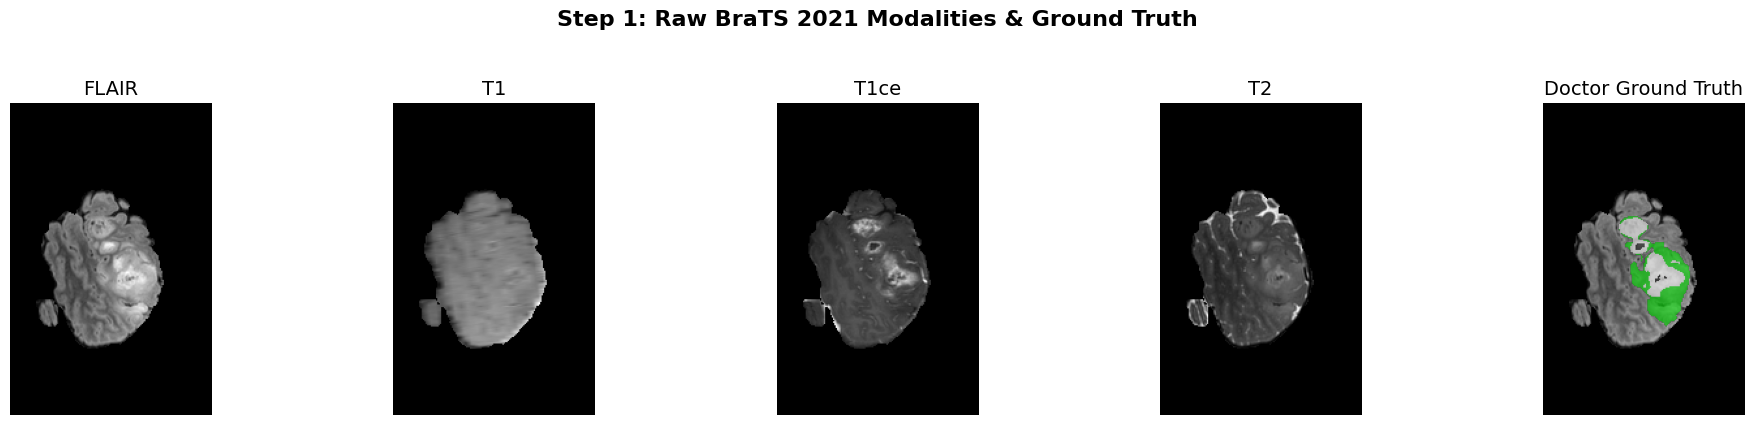

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Pick a random patient from your validation set
test_pid = val_ids[10]
raw_img, raw_gt = load_patient(test_pid)

# Find the slice with the biggest tumor
slice_idx = np.argmax(np.sum(raw_gt > 0, axis=(1, 2)))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Step 1: Raw BraTS 2021 Modalities & Ground Truth', fontsize=16, fontweight='bold', y=1.05)

modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
for i in range(4):
    axes[i].imshow(raw_img[slice_idx, :, :, i], cmap='gray')
    axes[i].set_title(modalities[i], fontsize=14)
    axes[i].axis('off')

# Plot the Ground Truth Mask
axes[4].imshow(raw_img[slice_idx, :, :, 0], cmap='gray') # FLAIR background
axes[4].imshow(np.ma.masked_where(raw_gt[slice_idx, :, :] == 0, raw_gt[slice_idx, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[4].set_title('Doctor Ground Truth', fontsize=14)
axes[4].axis('off')

plt.tight_layout()
plt.show()

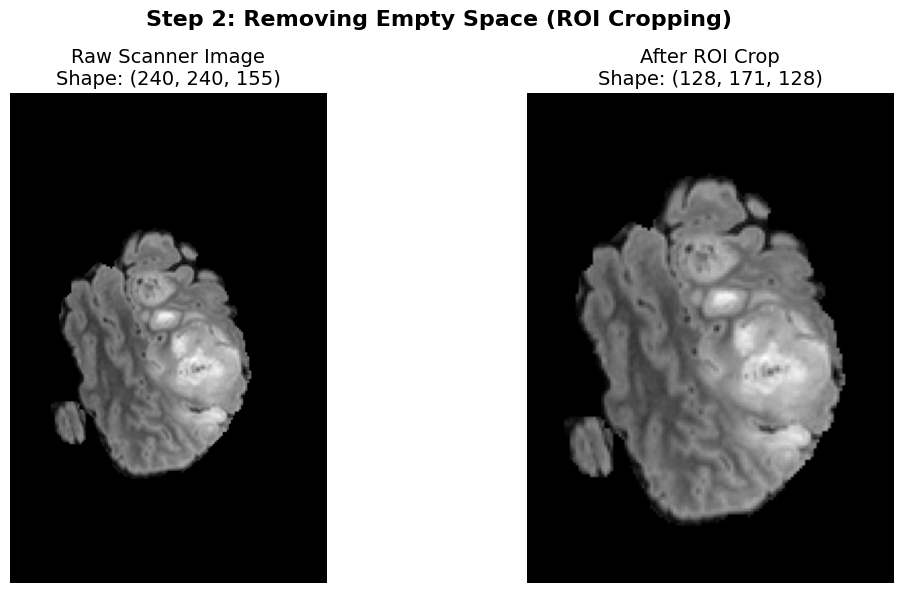

In [19]:
cropped_img, cropped_gt = crop_brain_roi(raw_img.copy(), raw_gt.copy())

# Find the new slice index in the cropped volume (since the Z-axis shrunk)
cropped_slice_idx = np.argmax(np.sum(cropped_gt > 0, axis=(1, 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Step 2: Removing Empty Space (ROI Cropping)', fontsize=16, fontweight='bold')

# Raw Brain with lots of black space
axes[0].imshow(raw_img[slice_idx, :, :, 0], cmap='gray')
axes[0].set_title(f'Raw Scanner Image\nShape: {raw_img.shape[:3]}', fontsize=14)
axes[0].axis('off')

# Cropped Brain
axes[1].imshow(cropped_img[cropped_slice_idx, :, :, 0], cmap='gray')
axes[1].set_title(f'After ROI Crop\nShape: {cropped_img.shape[:3]}', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

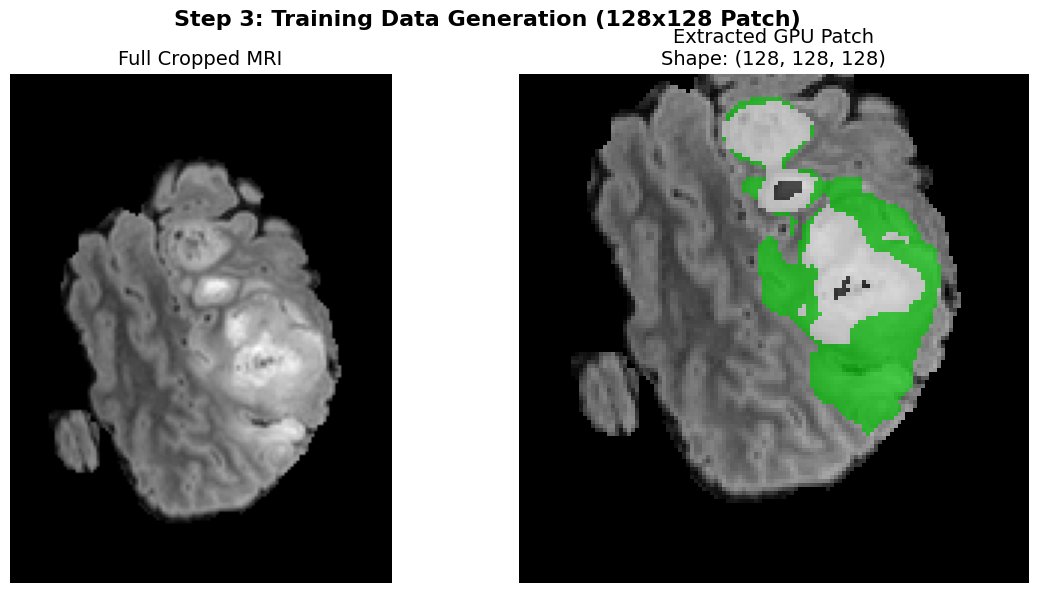

In [20]:
# Pad the cropped image so extraction doesn't fail, then extract a patch
padded_img, padded_gt = pad_for_training(cropped_img, cropped_gt,128)
patch_img, patch_gt = extract_patch(padded_img, padded_gt)

# Find where the tumor is inside the extracted 128x128 patch
patch_slice_idx = np.argmax(np.sum(patch_gt > 0, axis=(1, 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Step 3: Training Data Generation (128x128 Patch)', fontsize=16, fontweight='bold')

# Full Cropped Image (Context)
axes[0].imshow(padded_img[cropped_slice_idx, :, :, 0], cmap='gray')
axes[0].set_title('Full Cropped MRI', fontsize=14)
axes[0].axis('off')

# The Extracted Patch (What the model actually learns from)
axes[1].imshow(patch_img[patch_slice_idx, :, :, 0], cmap='gray')
axes[1].imshow(np.ma.masked_where(patch_gt[patch_slice_idx, :, :] == 0, patch_gt[patch_slice_idx, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[1].set_title(f'Extracted GPU Patch\nShape: {patch_img.shape[:3]}', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Running full volume clinical inference for final visualization...


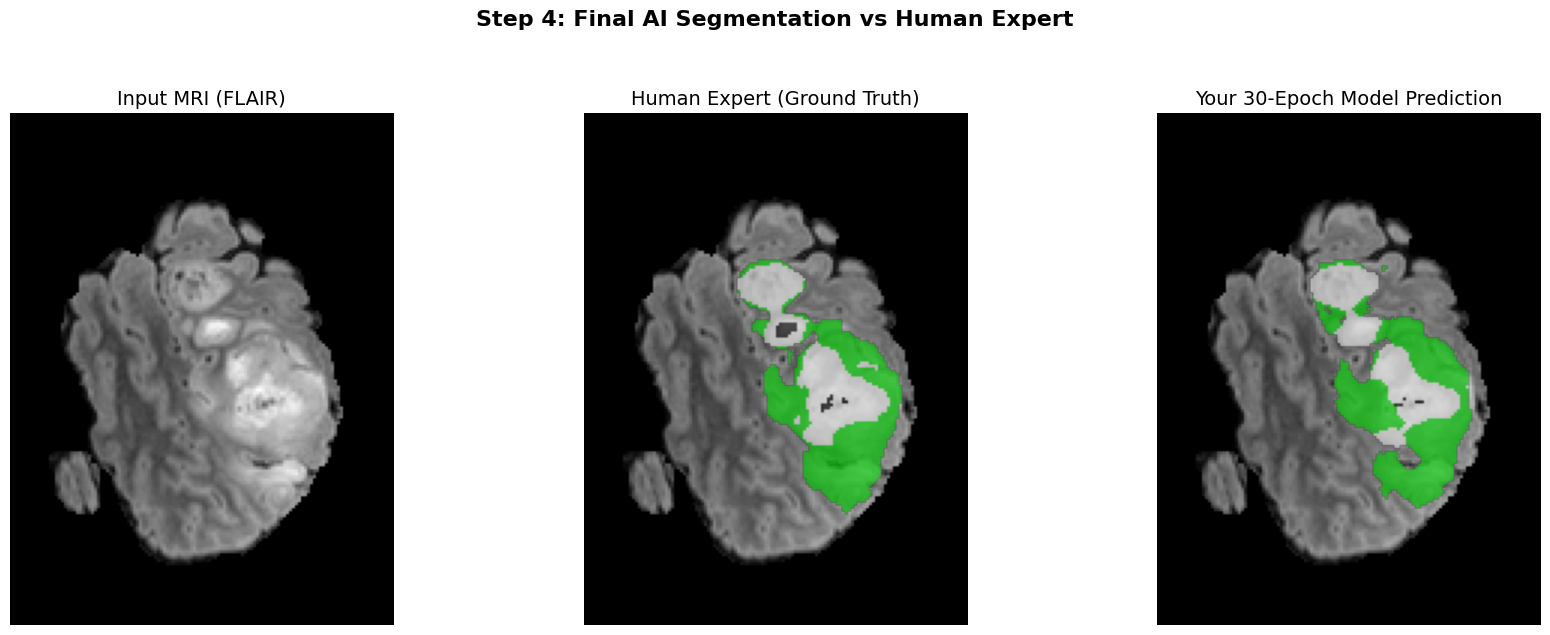

In [21]:
# Ensure your model is loaded before running this cell!
# final_model.load_weights(BEST_MODEL_PATH)

print("Running full volume clinical inference for final visualization...")
pred, gt = predict_patient(test_pid, final_model)

# Find the best slice to show off
final_slice_idx = np.argmax(np.sum(gt > 0, axis=(1, 2)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Step 4: Final AI Segmentation vs Human Expert', fontsize=16, fontweight='bold', y=1.05)

# 1. Base MRI
axes[0].imshow(cropped_img[final_slice_idx, :, :, 0], cmap='gray')
axes[0].set_title('Input MRI (FLAIR)', fontsize=14)
axes[0].axis('off')

# 2. Doctor Ground Truth
axes[1].imshow(cropped_img[final_slice_idx, :, :, 0], cmap='gray')
axes[1].imshow(np.ma.masked_where(gt[final_slice_idx, :, :] == 0, gt[final_slice_idx, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[1].set_title('Human Expert (Ground Truth)', fontsize=14)
axes[1].axis('off')

# 3. Your Model's Prediction
axes[2].imshow(cropped_img[final_slice_idx, :, :, 0], cmap='gray')
axes[2].imshow(np.ma.masked_where(pred[final_slice_idx, :, :] == 0, pred[final_slice_idx, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[2].set_title(f'Your 30-Epoch Model Prediction', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

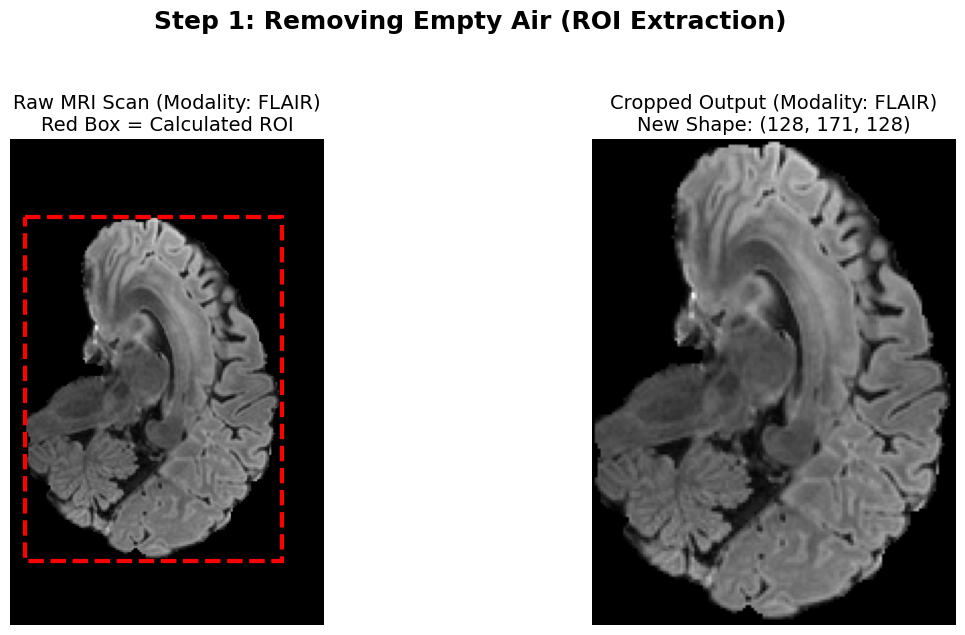

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Assuming test_pid and load_patient are already in memory
raw_img, raw_gt = load_patient(test_pid)

# 1. Manually calculate the bounding box coordinates just like your function does
brain_mask = raw_img[..., 0] > 0
coords = np.argwhere(brain_mask)
zmin, ymin, xmin = coords.min(axis=0)
zmax, ymax, xmax = coords.max(axis=0)

# 2. Pick the center slice of the brain to visualize
slice_idx = (zmin + zmax) // 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Step 1: Removing Empty Air (ROI Extraction)', fontsize=18, fontweight='bold', y=1.05)

# --- Plot A: Raw Image with Bounding Box ---
axes[0].imshow(raw_img[slice_idx, :, :, 0], cmap='gray')
axes[0].set_title('Raw MRI Scan (Modality: FLAIR)\nRed Box = Calculated ROI', fontsize=14)
axes[0].axis('off')

# Draw the Red Bounding Box
roi_width = xmax - xmin
roi_height = ymax - ymin
rect_roi = patches.Rectangle((xmin, ymin), roi_width, roi_height, 
                             linewidth=3, edgecolor='red', facecolor='none', linestyle='--')
axes[0].add_patch(rect_roi)

# --- Plot B: The Final Cropped Result ---
# Execute your actual crop function
cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)
cropped_slice_idx = slice_idx - zmin # Adjust slice index for the new smaller array

axes[1].imshow(cropped_img[cropped_slice_idx, :, :, 0], cmap='gray')
axes[1].set_title(f'Cropped Output (Modality: FLAIR)\nNew Shape: {cropped_img.shape[:3]}', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

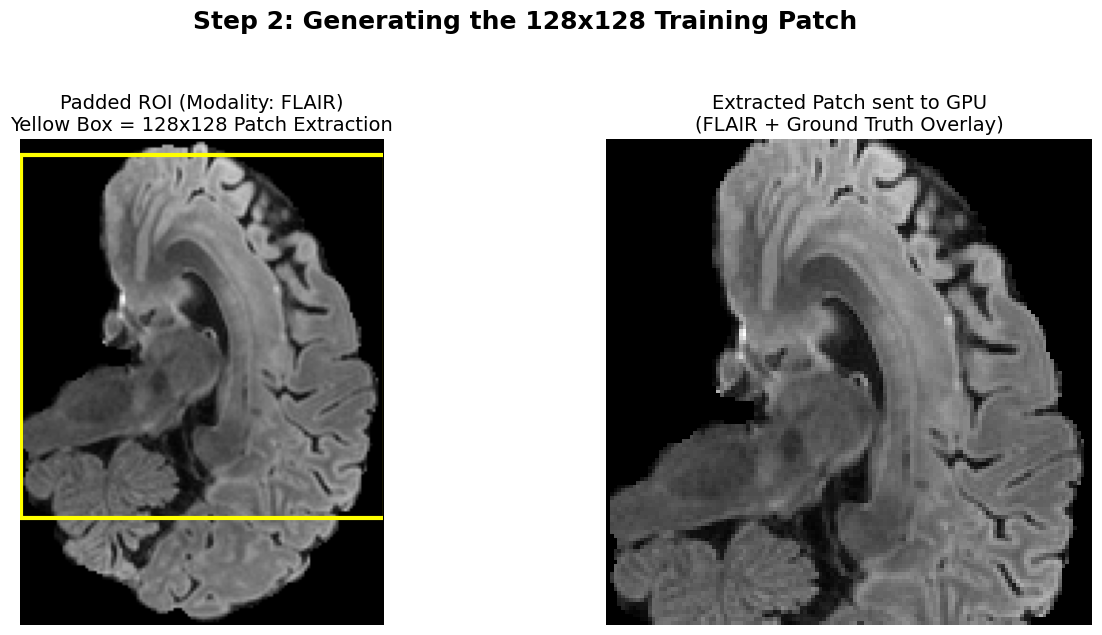

In [23]:
# 1. Pad the image using your function
padded_img, padded_gt = pad_for_training(cropped_img, cropped_gt,128)

# 2. Find a coordinate where the tumor exists to center our patch
tumor_coords = np.argwhere(padded_gt > 0)
cz, cy, cx = tumor_coords[len(tumor_coords)//2] # Pick a point roughly in the middle of the tumor

# 3. Apply the safety clip (just like your extract_patch function)
p = 128
cz = np.clip(cz, p//2, padded_img.shape[0] - p//2)
cy = np.clip(cy, p//2, padded_img.shape[1] - p//2)
cx = np.clip(cx, p//2, padded_img.shape[2] - p//2)

# Calculate the edges of the box
box_ymin, box_xmin = cy - p//2, cx - p//2

# 4. Extract that specific patch
patch_img = padded_img[cz-p//2 : cz+p//2, cy-p//2 : cy+p//2, cx-p//2 : cx+p//2]
patch_gt = padded_gt[cz-p//2 : cz+p//2, cy-p//2 : cy+p//2, cx-p//2 : cx+p//2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Step 2: Generating the 128x128 Training Patch', fontsize=18, fontweight='bold', y=1.05)

# --- Plot A: Padded Brain with Extraction Box ---
axes[0].imshow(padded_img[cz, :, :, 0], cmap='gray')
# Overlay the tumor lightly so we can see why it picked this spot
axes[0].imshow(np.ma.masked_where(padded_gt[cz, :, :] == 0, padded_gt[cz, :, :]), cmap='nipy_spectral', alpha=0.3)
axes[0].set_title('Padded ROI (Modality: FLAIR)\nYellow Box = 128x128 Patch Extraction', fontsize=14)
axes[0].axis('off')

# Draw the Yellow Patch Box
rect_patch = patches.Rectangle((box_xmin, box_ymin), 128, 128, 
                               linewidth=3, edgecolor='yellow', facecolor='none', linestyle='-')
axes[0].add_patch(rect_patch)

# --- Plot B: The Extracted Patch (What the Model Sees) ---
axes[1].imshow(patch_img[128//2, :, :, 0], cmap='gray')
axes[1].imshow(np.ma.masked_where(patch_gt[128//2, :, :] == 0, patch_gt[128//2, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[1].set_title('Extracted Patch sent to GPU\n(FLAIR + Ground Truth Overlay)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

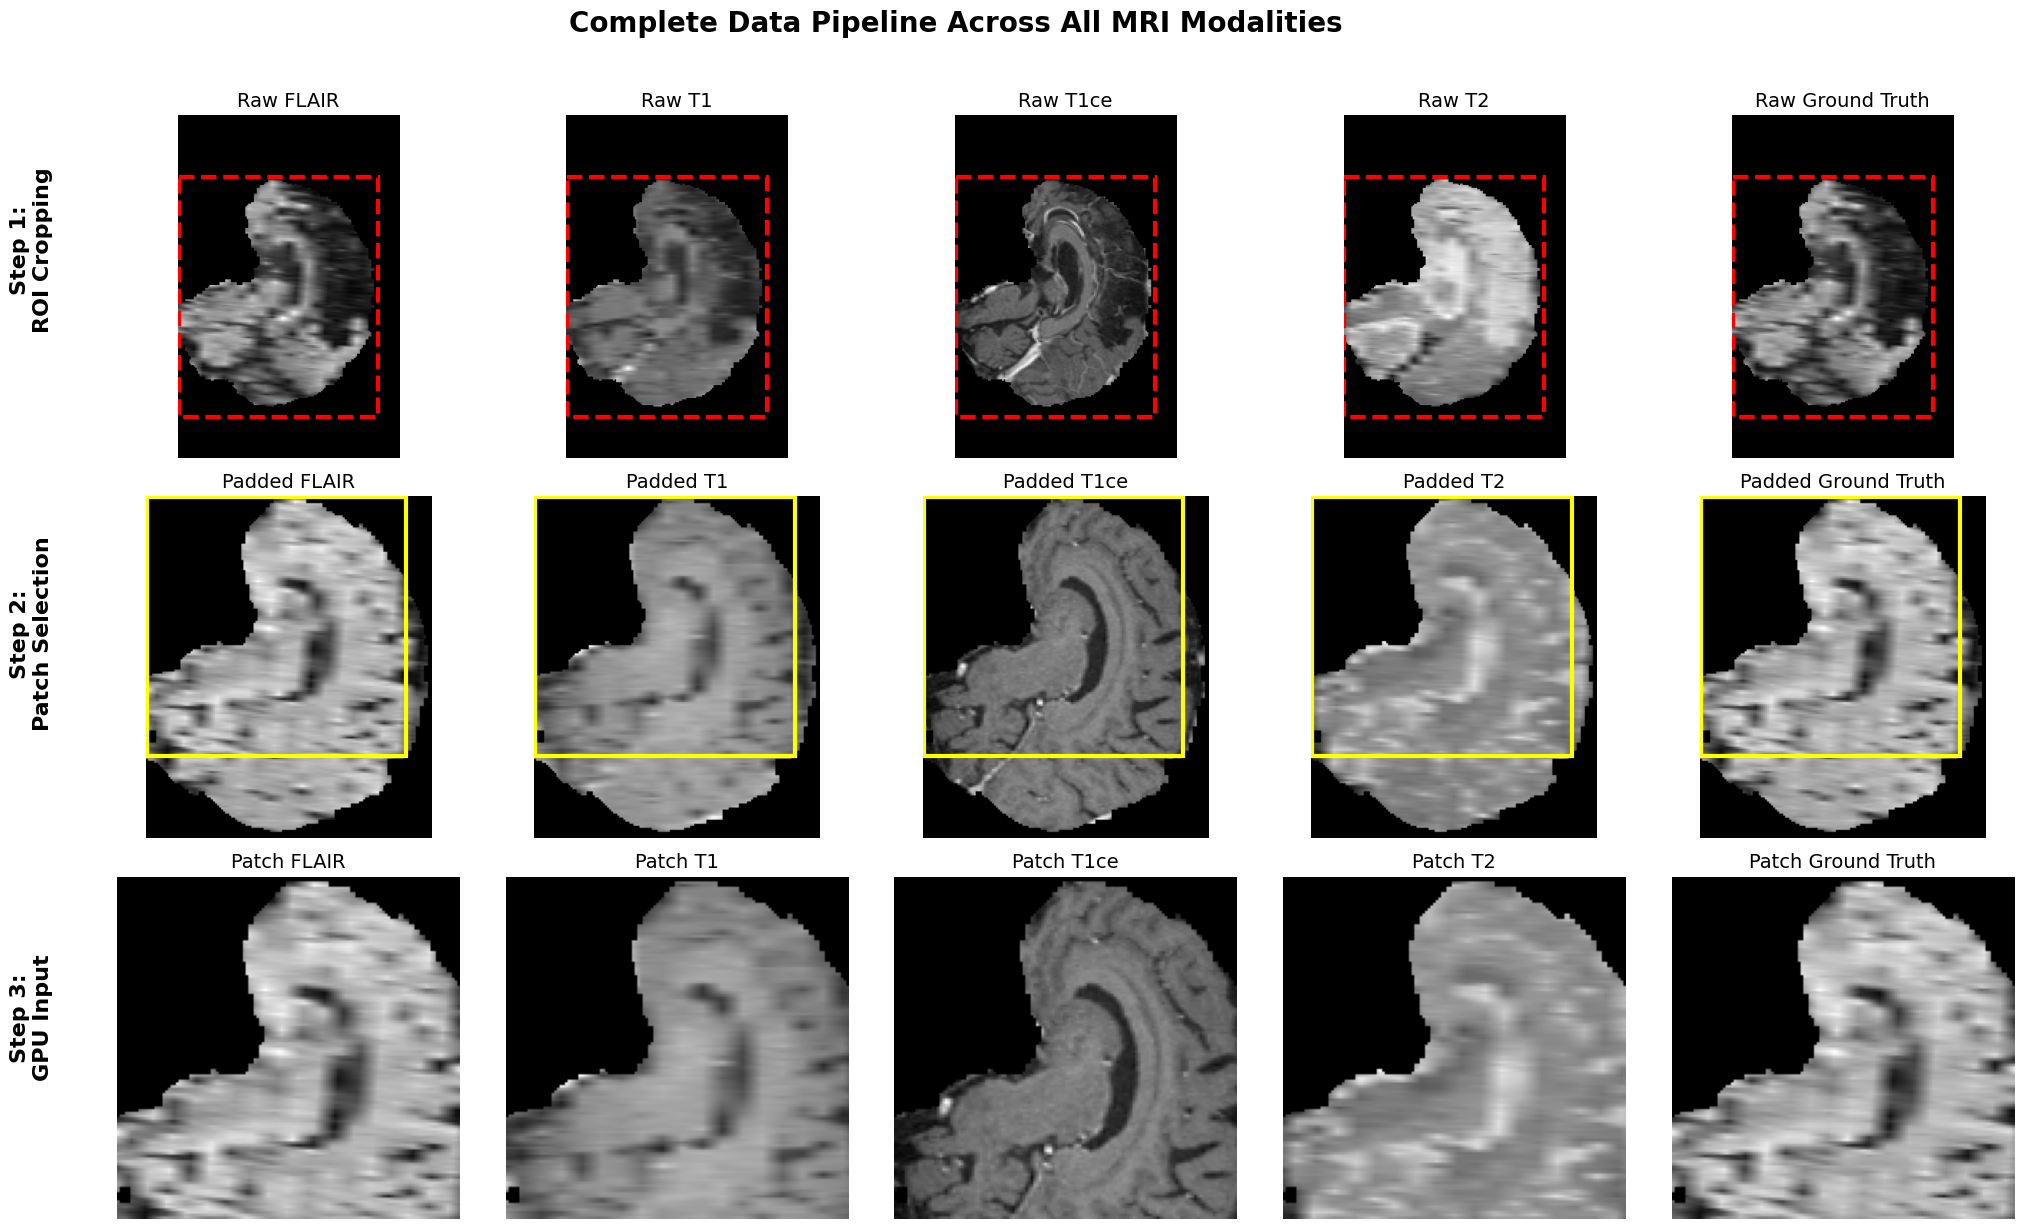

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Load a patient and find the best slice
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)

# Calculate ROI Bounding Box manually for visualization
brain_mask = raw_img[..., 0] > 0
coords = np.argwhere(brain_mask)
zmin, ymin, xmin = coords.min(axis=0)
zmax, ymax, xmax = coords.max(axis=0)

# Pick the center slice of the brain
slice_idx = (zmin + zmax) // 2

# 2. Process the image through your pipeline
cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)
padded_img, padded_gt = pad_for_training(cropped_img, cropped_gt,128)

# Calculate Patch Box manually for visualization
tumor_coords = np.argwhere(padded_gt > 0)
cz, cy, cx = tumor_coords[len(tumor_coords)//2] # Center on tumor
p = 128
cz = np.clip(cz, p//2, padded_img.shape[0] - p//2)
cy = np.clip(cy, p//2, padded_img.shape[1] - p//2)
cx = np.clip(cx, p//2, padded_img.shape[2] - p//2)

patch_img = padded_img[cz-p//2 : cz+p//2, cy-p//2 : cy+p//2, cx-p//2 : cx+p//2]
patch_gt = padded_gt[cz-p//2 : cz+p//2, cy-p//2 : cy+p//2, cx-p//2 : cx+p//2]

# 3. Setup the 3x5 Plot Grid
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle('Complete Data Pipeline Across All MRI Modalities', fontsize=20, fontweight='bold', y=1.02)

modalities = ['FLAIR', 'T1', 'T1ce', 'T2']

# --- ROW 1: RAW MRI with RED ROI BOX ---
roi_w, roi_h = xmax - xmin, ymax - ymin
for i in range(4):
    axes[0, i].imshow(raw_img[slice_idx, :, :, i], cmap='gray')
    axes[0, i].add_patch(patches.Rectangle((xmin, ymin), roi_w, roi_h, linewidth=3, edgecolor='red', facecolor='none', linestyle='--'))
    axes[0, i].set_title(f'Raw {modalities[i]}', fontsize=14)
    axes[0, i].axis('off')

# Row 1 Ground Truth
axes[0, 4].imshow(raw_img[slice_idx, :, :, 0], cmap='gray')
axes[0, 4].imshow(np.ma.masked_where(raw_gt[slice_idx, :, :] == 0, raw_gt[slice_idx, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[0, 4].add_patch(patches.Rectangle((xmin, ymin), roi_w, roi_h, linewidth=3, edgecolor='red', facecolor='none', linestyle='--'))
axes[0, 4].set_title('Raw Ground Truth', fontsize=14)
axes[0, 4].axis('off')


# --- ROW 2: CROPPED/PADDED MRI with YELLOW PATCH BOX ---
box_ymin, box_xmin = cy - p//2, cx - p//2
for i in range(4):
    axes[1, i].imshow(padded_img[cz, :, :, i], cmap='gray')
    axes[1, i].add_patch(patches.Rectangle((box_xmin, box_ymin), 128, 128, linewidth=3, edgecolor='yellow', facecolor='none', linestyle='-'))
    axes[1, i].set_title(f'Padded {modalities[i]}', fontsize=14)
    axes[1, i].axis('off')

# Row 2 Ground Truth
axes[1, 4].imshow(padded_img[cz, :, :, 0], cmap='gray')
axes[1, 4].imshow(np.ma.masked_where(padded_gt[cz, :, :] == 0, padded_gt[cz, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[1, 4].add_patch(patches.Rectangle((box_xmin, box_ymin), 128, 128, linewidth=3, edgecolor='yellow', facecolor='none', linestyle='-'))
axes[1, 4].set_title('Padded Ground Truth', fontsize=14)
axes[1, 4].axis('off')


# --- ROW 3: FINAL 128x128 GPU PATCHES ---
for i in range(4):
    axes[2, i].imshow(patch_img[128//2, :, :, i], cmap='gray')
    axes[2, i].set_title(f'Patch {modalities[i]}', fontsize=14)
    axes[2, i].axis('off')

# Row 3 Ground Truth
axes[2, 4].imshow(patch_img[128//2, :, :, 0], cmap='gray')
axes[2, 4].imshow(np.ma.masked_where(patch_gt[128//2, :, :] == 0, patch_gt[128//2, :, :]), cmap='nipy_spectral', alpha=0.7)
axes[2, 4].set_title('Patch Ground Truth', fontsize=14)
axes[2, 4].axis('off')

# Add Row Labels on the left
fig.text(0.08, 0.82, 'Step 1:\nROI Cropping', va='center', ha='center', rotation='vertical', fontsize=16, fontweight='bold')
fig.text(0.08, 0.50, 'Step 2:\nPatch Selection', va='center', ha='center', rotation='vertical', fontsize=16, fontweight='bold')
fig.text(0.08, 0.18, 'Step 3:\nGPU Input', va='center', ha='center', rotation='vertical', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0.1, 0, 1, 1]) # Shift everything slightly right to fit the text
plt.show()

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

# 1. Setup variables and find a good Z-slice with visible tumor
p = 128
tumor_coords = np.argwhere(padded_gt > 0)
best_z = tumor_coords[len(tumor_coords)//2][0]

# 2. Initialize the plot figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Dynamic 128x128 Patch Extraction During Training', fontsize=18, fontweight='bold')

# Left Plot: The Context (Static Background)
axes[0].imshow(padded_img[best_z, :, :, 0], cmap='gray')
axes[0].set_title('Full Padded MRI (FLAIR)', fontsize=14)
axes[0].axis('off')

# Create the yellow jumping rectangle
rect = patches.Rectangle((0, 0), p, p, linewidth=4, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)

# Right Plot: The Extracted Patch (Dynamic)
# Initialize with an empty black square that will update every frame
patch_display = axes[1].imshow(np.zeros((p, p)), cmap='gray', vmin=padded_img.min(), vmax=padded_img.max())
axes[1].set_title('Extracted Patch sent to GPU', fontsize=14)
axes[1].axis('off')

# 3. The Animation Function
def update(frame):
    # Frame 0: Target the tumor (40% chance in your actual code)
    if frame == 0:
        target_coords = np.argwhere(padded_gt[best_z] > 0)
    # Frame 1: Target healthy brain tissue (40% chance)
    elif frame == 1:
        target_coords = np.argwhere((padded_img[best_z, ..., 0] > 0) & (padded_gt[best_z] == 0))
    # Frame 2: Target near the edge/background (20% chance)
    else:
        target_coords = np.argwhere(padded_img[best_z, ..., 0] > -5)
        
    # Pick a random coordinate from the chosen target area
    if len(target_coords) > 0:
        cy, cx = target_coords[np.random.randint(0, len(target_coords))]
    else:
        cy, cx = padded_img.shape[1]//2, padded_img.shape[2]//2

    # Apply the exact safety clip your code uses
    cy = np.clip(cy, p//2, padded_img.shape[1] - p//2)
    cx = np.clip(cx, p//2, padded_img.shape[2] - p//2)

    # Move the yellow box
    rect.set_xy((cx - p//2, cy - p//2))

    # Update the right-side patch image
    extracted = padded_img[best_z, cy-p//2 : cy+p//2, cx-p//2 : cx+p//2, 0]
    patch_display.set_data(extracted)
    
    return rect, patch_display

# 4. Compile the Animation
print("Generating GIF frames... please wait.")
ani = animation.FuncAnimation(fig, update, frames=3, interval=1200, blit=True)

# 5. Save the GIF to your Kaggle working directory
gif_path = '/kaggle/working/patch_extraction_demo.gif'
ani.save(gif_path, writer='pillow', fps=1)

print(f"✅ GIF successfully saved to: {gif_path}")

# Close the static plot so it doesn't double-print in the notebook
plt.close()

Generating GIF frames... please wait.
✅ GIF successfully saved to: /kaggle/working/patch_extraction_demo.gif


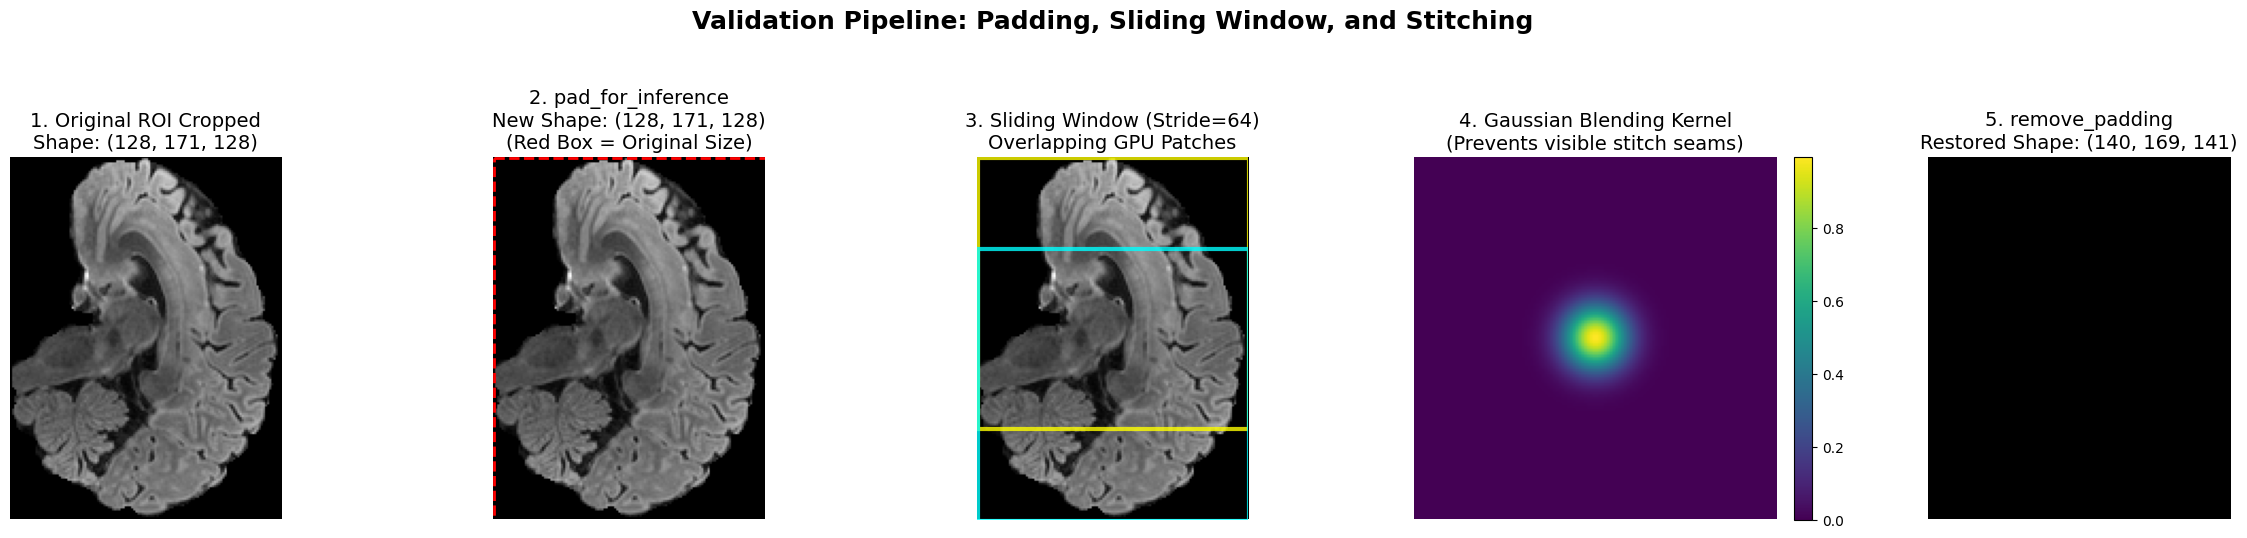

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Load the patient and get the initial ROI crop
test_pid = val_ids[10]
raw_img, raw_gt = load_patient(test_pid)
cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)

# 2. Apply Inference Padding
p = 128
padded_img, pad_before, pad_after = pad_for_inference(cropped_img, patch_size=p)

# Find the best Z-slice to visualize
z_center = padded_img.shape[0] // 2

# 3. Get the Gaussian Weight Map (Extract the center slice of the 3D kernel)
weight_3d = gaussian_kernel(p)
weight_2d = weight_3d[p//2, :, :, 0]

# 4. Set up the Figure
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle('Validation Pipeline: Padding, Sliding Window, and Stitching', fontsize=18, fontweight='bold', y=1.05)

# --- Plot 1: The Cropped ROI ---
axes[0].imshow(cropped_img[cropped_img.shape[0]//2, :, :, 0], cmap='gray')
axes[0].set_title(f'1. Original ROI Cropped\nShape: {cropped_img.shape[:3]}', fontsize=14)
axes[0].axis('off')

# --- Plot 2: pad_before and pad_after ---
axes[1].imshow(padded_img[z_center, :, :, 0], cmap='gray')
# Draw a red box showing exactly where the original image sits inside the padding
orig_y, orig_x = pad_before[1], pad_before[2]
orig_h, orig_w = cropped_img.shape[1], cropped_img.shape[2]
rect_orig = patches.Rectangle((orig_x, orig_y), orig_w, orig_h, 
                              linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
axes[1].add_patch(rect_orig)
axes[1].set_title(f'2. pad_for_inference\nNew Shape: {padded_img.shape[:3]}\n(Red Box = Original Size)', fontsize=14)
axes[1].axis('off')

# --- Plot 3: The Sliding Window Concept ---
axes[2].imshow(padded_img[z_center, :, :, 0], cmap='gray')
axes[2].set_title(f'3. Sliding Window (Stride={STRIDE})\nOverlapping GPU Patches', fontsize=14)
axes[2].axis('off')

# Calculate sliding window steps for the X and Y axes
y_steps = list(range(0, padded_img.shape[1] - p + 1, STRIDE))
if not y_steps or y_steps[-1] != padded_img.shape[1] - p: y_steps.append(padded_img.shape[1] - p)

x_steps = list(range(0, padded_img.shape[2] - p + 1, STRIDE))
if not x_steps or x_steps[-1] != padded_img.shape[2] - p: x_steps.append(padded_img.shape[2] - p)

# Draw yellow boxes for the first few sliding windows
colors = ['yellow', 'cyan', 'lime', 'magenta']
color_idx = 0
for yy in y_steps[:2]:  # Just show the first 2 rows to keep it readable
    for xx in x_steps[:2]: # Just show the first 2 cols
        rect_window = patches.Rectangle((xx, yy), p, p, 
                                        linewidth=3, edgecolor=colors[color_idx % len(colors)], facecolor='none', alpha=0.8)
        axes[2].add_patch(rect_window)
        color_idx += 1

# --- Plot 4: The Gaussian Kernel ---
im = axes[3].imshow(weight_2d, cmap='viridis')
axes[3].set_title('4. Gaussian Blending Kernel\n(Prevents visible stitch seams)', fontsize=14)
axes[3].axis('off')
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

# --- Plot 5: remove_padding ---
# We simulate a prediction by taking the padded ground truth and removing the padding
padded_pred_sim = padded_gt.copy()
final_trimmed_pred = remove_padding(padded_pred_sim, pad_before, pad_after)

axes[4].imshow(final_trimmed_pred[cropped_img.shape[0]//2, :, :], cmap='nipy_spectral')
axes[4].set_title(f'5. remove_padding\nRestored Shape: {final_trimmed_pred.shape[:3]}', fontsize=14)
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np
import os

# 1. Setup Data (Assuming functions are in memory)
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)
cropped_img, _ = crop_brain_roi(raw_img, raw_gt)

# Pad for inference
p = 128
stride = 64
padded_img, _, _ = pad_for_inference(cropped_img, patch_size=p)

# Pick the center Z-slice for the 2D animation
z_center = padded_img.shape[0] // 2
slice_img = padded_img[z_center, :, :, 0] # FLAIR channel

# Get 2D Gaussian Kernel for blending simulation
weight_2d = gaussian_kernel(p)[p//2, :, :, 0]

# 2. Calculate the exact Sliding Window coordinates
y_steps = list(range(0, slice_img.shape[0] - p + 1, stride))
if not y_steps or y_steps[-1] != slice_img.shape[0] - p: y_steps.append(slice_img.shape[0] - p)

x_steps = list(range(0, slice_img.shape[1] - p + 1, stride))
if not x_steps or x_steps[-1] != slice_img.shape[1] - p: x_steps.append(slice_img.shape[1] - p)

coords = [(yy, xx) for yy in y_steps for xx in x_steps]

# 3. Setup the Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Clinical Inference: Sliding Window & Gaussian Stitching', fontsize=18, fontweight='bold')

# Left Plot: The MRI and the moving scanner box
axes[0].imshow(slice_img, cmap='gray')
axes[0].set_title('GPU Scanning (Stride=64)', fontsize=14)
axes[0].axis('off')

# The moving red rectangle
scanner_box = patches.Rectangle((0, 0), p, p, linewidth=4, edgecolor='red', facecolor='none')
axes[0].add_patch(scanner_box)

# Right Plot: The blank canvas where the AI reconstructs the image
canvas = np.zeros_like(slice_img, dtype=np.float32)
weight_map = np.zeros_like(slice_img, dtype=np.float32)
reconstruction_display = axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=np.max(slice_img))
axes[1].set_title('Smooth Patch Reconstruction', fontsize=14)
axes[1].axis('off')

# 4. The Animation Function
def update(frame):
    if frame < len(coords):
        yy, xx = coords[frame]
        
        # Move the scanner box
        scanner_box.set_xy((xx, yy))
        
        # Simulate the AI extracting the patch and applying the Gaussian weight
        extracted_patch = slice_img[yy:yy+p, xx:xx+p]
        
        # Add the weighted patch to our blank canvas
        canvas[yy:yy+p, xx:xx+p] += extracted_patch * weight_2d
        weight_map[yy:yy+p, xx:xx+p] += weight_2d
        
        # To display it correctly, divide by the current weight_map (avoiding divide-by-zero)
        safe_weight = np.where(weight_map == 0, 1.0, weight_map)
        current_reconstruction = canvas / safe_weight
        
        reconstruction_display.set_data(current_reconstruction)
        
    return scanner_box, reconstruction_display

# 5. Compile and Save the GIF
print(f"Generating GIF with {len(coords)} frames... please wait.")
# Add a few extra frames at the end so it pauses on the fully constructed image
total_frames = len(coords) + 3 

ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=400, blit=True)

gif_path = '/kaggle/working/sliding_window_validation.gif'
ani.save(gif_path, writer='pillow', fps=3)

print(f"✅ GIF successfully saved to: {gif_path}")
plt.close()

Generating GIF with 4 frames... please wait.
✅ GIF successfully saved to: /kaggle/working/sliding_window_validation.gif


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import imageio
import os

print("Starting Video Generation Pipeline...")

# 1. Setup Data and Folders
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)
cropped_img, _ = crop_brain_roi(raw_img, raw_gt)

p = 128
stride = 64
padded_img, pad_before, pad_after = pad_for_inference(cropped_img, patch_size=p)
z_center = padded_img.shape[0] // 2
slice_img = padded_img[z_center, :, :, 0] # FLAIR
weight_2d = gaussian_kernel(p)[p//2, :, :, 0]

# Create a temporary folder to hold our video frames
FRAME_DIR = '/kaggle/working/video_frames'
os.makedirs(FRAME_DIR, exist_ok=True)
frame_files = []

# Helper function to save frames
def save_frame(fig, step_num, repeat=1):
    filename = f"{FRAME_DIR}/frame_{step_num:04d}.png"
    fig.savefig(filename, bbox_inches='tight', dpi=100)
    for _ in range(repeat):
        frame_files.append(filename)

# 2. Setup the Master Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plt.tight_layout(pad=4.0)

# --- SCENE 1: The Cropped Brain ---
axes[0].clear(); axes[1].clear()
fig.suptitle('Validation Phase 1: Original Cropped ROI', fontsize=20, fontweight='bold')
# We simulate the unpadded view by cropping the padded slice back down
orig_y, orig_x = pad_before[1], pad_before[2]
orig_h, orig_w = cropped_img.shape[1], cropped_img.shape[2]
axes[0].imshow(slice_img[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w], cmap='gray')
axes[0].set_title('Hospital Scanner MRI', fontsize=14); axes[0].axis('off')
axes[1].imshow(np.zeros((orig_h, orig_w)), cmap='gray')
axes[1].set_title('Empty Canvas', fontsize=14); axes[1].axis('off')
save_frame(fig, 1, repeat=5) # Hold this scene for 5 frames

# --- SCENE 2: Adding the Padding ---
axes[0].clear(); axes[1].clear()
fig.suptitle('Validation Phase 2: Adding Safety Padding (pad_for_inference)', fontsize=20, fontweight='bold')
axes[0].imshow(slice_img, cmap='gray')
rect_orig = patches.Rectangle((orig_x, orig_y), orig_w, orig_h, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
axes[0].add_patch(rect_orig)
axes[0].set_title('Brain Centered in 128x128 Minimum Bounds', fontsize=14); axes[0].axis('off')

canvas = np.zeros_like(slice_img, dtype=np.float32)
weight_map = np.zeros_like(slice_img, dtype=np.float32)
axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=np.max(slice_img))
axes[1].set_title('Padded Canvas', fontsize=14); axes[1].axis('off')
save_frame(fig, 2, repeat=5)

# --- SCENE 3: Sliding Window & Gaussian Blending ---
fig.suptitle('Validation Phase 3: GPU Sliding Window & Gaussian Stitching', fontsize=20, fontweight='bold')
y_steps = list(range(0, slice_img.shape[0] - p + 1, stride))
if not y_steps or y_steps[-1] != slice_img.shape[0] - p: y_steps.append(slice_img.shape[0] - p)
x_steps = list(range(0, slice_img.shape[1] - p + 1, stride))
if not x_steps or x_steps[-1] != slice_img.shape[1] - p: x_steps.append(slice_img.shape[1] - p)

frame_count = 3
for yy in y_steps:
    for xx in x_steps:
        axes[0].clear(); axes[1].clear()
        
        # Left Side: Scanner
        axes[0].imshow(slice_img, cmap='gray')
        axes[0].add_patch(patches.Rectangle((orig_x, orig_y), orig_w, orig_h, linewidth=1, edgecolor='red', facecolor='none', linestyle='--'))
        axes[0].add_patch(patches.Rectangle((xx, yy), p, p, linewidth=4, edgecolor='yellow', facecolor='none'))
        axes[0].set_title('GPU Scanning (Stride=64)', fontsize=14); axes[0].axis('off')
        
        # Right Side: AI Reconstruction
        extracted_patch = slice_img[yy:yy+p, xx:xx+p]
        canvas[yy:yy+p, xx:xx+p] += extracted_patch * weight_2d
        weight_map[yy:yy+p, xx:xx+p] += weight_2d
        safe_weight = np.where(weight_map == 0, 1.0, weight_map)
        
        axes[1].imshow(canvas / safe_weight, cmap='gray', vmin=0, vmax=np.max(slice_img))
        axes[1].set_title('Smooth Gaussian Reconstruction', fontsize=14); axes[1].axis('off')
        
        save_frame(fig, frame_count, repeat=2)
        frame_count += 1

# --- SCENE 4: Removing Padding ---
axes[0].clear(); axes[1].clear()
fig.suptitle('Validation Phase 4: Removing Padding (remove_padding)', fontsize=20, fontweight='bold')
final_reconstruction = canvas / safe_weight
trimmed_final = final_reconstruction[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]

axes[0].imshow(slice_img[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w], cmap='gray')
axes[0].set_title('Original Hospital MRI', fontsize=14); axes[0].axis('off')
axes[1].imshow(trimmed_final, cmap='gray')
axes[1].set_title('Final Trimmed AI Output', fontsize=14); axes[1].axis('off')
save_frame(fig, frame_count, repeat=10) # Hold final frame so panel can see it

plt.close(fig) # Close the plot so it doesn't clutter the notebook

# 3. Compile the Frames into a Video/GIF
print("Compiling frames into an MP4 video...")
video_path = '/kaggle/working/validation_masterclass.mp4'

# Read images and write to video
with imageio.get_writer(video_path, fps=4) as writer:
    for filename in frame_files:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"✅ Masterpiece Video successfully saved to: {video_path}")

Starting Video Generation Pipeline...
Compiling frames into an MP4 video...


/tmp/ipykernel_24/1201212721.py:114: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1159, 626) to (1168, 640) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x18e45040] Stream #0: not enough frames to estimate rate; consider increasing probesize


✅ Masterpiece Video successfully saved to: /kaggle/working/validation_masterclass.mp4


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import imageio
import os

print("Starting Slow-Motion Multi-Class Video Generation...")

# 1. Setup Data
# 1. Setup Data
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)

# Properly grab BOTH the cropped image and the cropped ground truth
cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)

p = 128
stride = 64

# Pad the 4D MRI using your function
padded_img, pad_before, pad_after = pad_for_inference(cropped_img, patch_size=p)

# Manually pad the 3D Ground Truth using the EXACT same calculated padding values
padded_gt = np.pad(cropped_gt, 
                   ((pad_before[0], pad_after[0]), 
                    (pad_before[1], pad_after[1]), 
                    (pad_before[2], pad_after[2])), 
                   mode="constant")

z_center = padded_img.shape[0] // 2
slice_img = padded_img[z_center, :, :, 0] # FLAIR
slice_gt = padded_gt[z_center, :, :]      # Ground Truth for this slice

weight_2d = gaussian_kernel(p)[p//2, :, :, 0]
weight_expanded = np.expand_dims(weight_2d, axis=-1) # For 4-channel multiplication

# --- Custom Colormap for Classes ---
# 0: Black (Background), 1: Red (Necrotic), 2: Green (Edema), 3: Yellow (Enhancing)
cmap_custom = mcolors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# --- Custom Colormap for Classes ---
# 0: Black (Background), 1: Red (Necrotic), 2: Green (Edema), 3: Yellow (Enhancing)
cmap_custom = mcolors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# 2. Setup Video Writer
FRAME_DIR = '/kaggle/working/slow_video_frames'
os.makedirs(FRAME_DIR, exist_ok=True)
frame_files = []

def save_frame(fig, step_name, repeat=1):
    filename = f"{FRAME_DIR}/frame_{len(frame_files):04d}_{step_name}.png"
    fig.savefig(filename, bbox_inches='tight', dpi=120)
    for _ in range(repeat):
        frame_files.append(filename)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.tight_layout(pad=5.0)

# --- SCENE 1: Marking the Tumor (Pre-Scan) ---
axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 1: Locating the Tumor & Defining Classes', fontsize=22, fontweight='bold')

orig_y, orig_x = pad_before[1], pad_before[2]
orig_h, orig_w = cropped_img.shape[1], cropped_img.shape[2]

# Draw the Raw MRI
axes[0].imshow(slice_img, cmap='gray')
axes[0].set_title('Patient MRI (FLAIR)', fontsize=16); axes[0].axis('off')

# Find tumor bounding box to draw an arrow/box
tumor_y, tumor_x = np.where(slice_gt > 0)
if len(tumor_y) > 0:
    ty_min, ty_max = tumor_y.min(), tumor_y.max()
    tx_min, tx_max = tumor_x.min(), tumor_x.max()
    # Draw a bright cyan box around the tumor region
    axes[0].add_patch(patches.Rectangle((tx_min-10, ty_min-10), (tx_max-tx_min)+20, (ty_max-ty_min)+20, 
                                        linewidth=3, edgecolor='cyan', facecolor='none'))
    axes[0].text(tx_min-10, ty_min-15, "Tumor Located Here", color='cyan', fontsize=14, fontweight='bold')

# Draw the Ground Truth with explicit class colors
axes[1].imshow(slice_img, cmap='gray')
im_gt = axes[1].imshow(np.ma.masked_where(slice_gt == 0, slice_gt), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Doctor Ground Truth Classes', fontsize=16); axes[1].axis('off')

# Add a visual legend
legend_elements = [
    patches.Patch(facecolor='green', label='Edema (Class 2)'),
    patches.Patch(facecolor='red', label='Necrotic Core (Class 1)'),
    patches.Patch(facecolor='yellow', label='Enhancing (Class 3)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12)

# Hold this scene for a long time (e.g., 6 seconds) so you can explain it
save_frame(fig, "pre_scan", repeat=15) 


# --- SCENE 2: The Slow Sliding Window & Class Assignment ---
fig.suptitle('Phase 2: AI Assigning Classes via Sliding Window', fontsize=22, fontweight='bold')

# We use a 4-channel canvas to simulate softmax probabilities being added up
canvas_probs = np.zeros((slice_img.shape[0], slice_img.shape[1], 4), dtype=np.float32)

y_steps = list(range(0, slice_img.shape[0] - p + 1, stride))
if not y_steps or y_steps[-1] != slice_img.shape[0] - p: y_steps.append(slice_img.shape[0] - p)
x_steps = list(range(0, slice_img.shape[1] - p + 1, stride))
if not x_steps or x_steps[-1] != slice_img.shape[1] - p: x_steps.append(slice_img.shape[1] - p)

for yy in y_steps:
    for xx in x_steps:
        axes[0].clear(); axes[1].clear()
        
        # Scanner Side
        axes[0].imshow(slice_img, cmap='gray')
        axes[0].add_patch(patches.Rectangle((xx, yy), p, p, linewidth=4, edgecolor='white', facecolor='none'))
        axes[0].set_title('AI Processing $128 \\times 128$ Block', fontsize=16); axes[0].axis('off')
        
        # Simulate Model Prediction (One-hot encoding the ground truth patch)
        patch_gt = slice_gt[yy:yy+p, xx:xx+p]
        simulated_softmax = np.eye(4)[patch_gt.astype(int)] # Shape: (128, 128, 4)
        
        # Apply Gaussian blending to the probabilities
        canvas_probs[yy:yy+p, xx:xx+p] += simulated_softmax * weight_expanded
        
        # Calculate the final class by taking the argmax of the accumulated probabilities
        current_prediction = np.argmax(canvas_probs, axis=-1)
        
        # Display the emerging classes
        axes[1].imshow(slice_img, cmap='gray') # Show brain in background
        axes[1].imshow(np.ma.masked_where(current_prediction == 0, current_prediction), 
                       cmap=cmap_custom, norm=norm_custom, alpha=0.9)
        axes[1].set_title('Real-Time Multi-Class Reconstruction', fontsize=16); axes[1].axis('off')
        
        # Hold each stride step for longer so it moves slowly
        save_frame(fig, f"scan_{yy}_{xx}", repeat=3)

# --- SCENE 3: The Final Trimmed Output ---
axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 3: Final Output After Removing Padding', fontsize=22, fontweight='bold')

final_prediction = np.argmax(canvas_probs, axis=-1)
trimmed_pred = final_prediction[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]
trimmed_img = slice_img[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]

axes[0].imshow(trimmed_img, cmap='gray')
axes[0].set_title('Original Brain Dimensions', fontsize=16); axes[0].axis('off')

axes[1].imshow(trimmed_img, cmap='gray')
axes[1].imshow(np.ma.masked_where(trimmed_pred == 0, trimmed_pred), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Final Clinical AI Prediction', fontsize=16); axes[1].axis('off')

# Hold the final result for a long time
save_frame(fig, "final", repeat=20)

plt.close(fig)

# 3. Compile the Video at a slower FPS
print("Compiling slow-motion video...")
video_path = '/kaggle/working/slow_multiclass_validation.mp4'

# FPS = 2 means each frame stays on screen for half a second. Very easy to follow.
with imageio.get_writer(video_path, fps=2) as writer:
    for filename in frame_files:
        image = imageio.imread(filename)
        writer.append_data(image)

print(f"✅ Slow-Motion Video successfully saved to: {video_path}")

Starting Slow-Motion Multi-Class Video Generation...


/tmp/ipykernel_24/408459671.py:168: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1474, 735) to (1488, 736) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Compiling slow-motion video...


[rawvideo @ 0x3dbd3040] Stream #0: not enough frames to estimate rate; consider increasing probesize


✅ Slow-Motion Video successfully saved to: /kaggle/working/slow_multiclass_validation.mp4


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import imageio.v2 as imageio # Updated to v2 to fix deprecation warning
from PIL import Image        # Added PIL for guaranteed frame resizing
import os

print("Starting Cinematic Multi-Class Video Generation...")

# ==========================================
# 1. SETUP DATA (WITH THE 3D PADDING FIX)
# ==========================================
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)

cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)

p = 128
stride = 64

padded_img, pad_before, pad_after = pad_for_inference(cropped_img, patch_size=p)

padded_gt = np.pad(cropped_gt, 
                   ((pad_before[0], pad_after[0]), 
                    (pad_before[1], pad_after[1]), 
                    (pad_before[2], pad_after[2])), 
                   mode="constant")

z_center = padded_img.shape[0] // 2
slice_img = padded_img[z_center, :, :, 0] # FLAIR
slice_gt = padded_gt[z_center, :, :]      # Ground Truth for this slice

weight_2d = gaussian_kernel(p)[p//2, :, :, 0]
weight_expanded = np.expand_dims(weight_2d, axis=-1)

# Custom Colormap for Classes
cmap_custom = mcolors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# ==========================================
# 2. SETUP VIDEO WRITER & TITLE CARDS
# ==========================================
FRAME_DIR = '/kaggle/working/cinematic_video_frames'
os.makedirs(FRAME_DIR, exist_ok=True)
frame_files = []

def save_frame(fig, step_name, repeat=1):
    filename = f"{FRAME_DIR}/frame_{len(frame_files):04d}_{step_name}.png"
    # Removed bbox_inches='tight' so Matplotlib doesn't crop edges
    fig.savefig(filename, dpi=120) 
    for _ in range(repeat):
        frame_files.append(filename)

# --- NEW FUNCTION: Cinematic Title Cards ---
def add_title_card(title_text, step_name, repeat=6):
    """Generates a black screen with white text to introduce a phase."""
    fig_title, ax_title = plt.subplots(figsize=(16, 7))
    fig_title.patch.set_facecolor('black')
    ax_title.set_facecolor('black')
    ax_title.text(0.5, 0.5, title_text, color='white', fontsize=35, 
                  ha='center', va='center', fontweight='bold')
    ax_title.axis('off')
    
    filename = f"{FRAME_DIR}/frame_{len(frame_files):04d}_{step_name}.png"
    # Removed bbox_inches='tight' here as well
    fig_title.savefig(filename, dpi=120, facecolor='black')
    for _ in range(repeat):
        frame_files.append(filename)
    plt.close(fig_title)

# Main figure for the actual medical images
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.tight_layout(pad=5.0)

# ==========================================
# SCENE 1: Marking the Tumor (Pre-Scan)
# ==========================================
# Insert Title Card (Holds for ~3 seconds at 2 FPS)
add_title_card("Phase 1\n\nLocating the Tumor & Defining Classes", "title_1", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 1: Locating the Tumor & Defining Classes', fontsize=22, fontweight='bold')

orig_y, orig_x = pad_before[1], pad_before[2]
orig_h, orig_w = cropped_img.shape[1], cropped_img.shape[2]

axes[0].imshow(slice_img, cmap='gray')
axes[0].set_title('Patient MRI (FLAIR)', fontsize=16); axes[0].axis('off')

tumor_y, tumor_x = np.where(slice_gt > 0)
if len(tumor_y) > 0:
    ty_min, ty_max = tumor_y.min(), tumor_y.max()
    tx_min, tx_max = tumor_x.min(), tumor_x.max()
    axes[0].add_patch(patches.Rectangle((tx_min-10, ty_min-10), (tx_max-tx_min)+20, (ty_max-ty_min)+20, 
                                        linewidth=3, edgecolor='cyan', facecolor='none'))
    axes[0].text(tx_min-10, ty_min-15, "Tumor Located Here", color='cyan', fontsize=14, fontweight='bold')

axes[1].imshow(slice_img, cmap='gray')
im_gt = axes[1].imshow(np.ma.masked_where(slice_gt == 0, slice_gt), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Doctor Ground Truth Classes', fontsize=16); axes[1].axis('off')

legend_elements = [
    patches.Patch(facecolor='green', label='Edema (Class 2)'),
    patches.Patch(facecolor='red', label='Necrotic Core (Class 1)'),
    patches.Patch(facecolor='yellow', label='Enhancing (Class 3)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12)

save_frame(fig, "pre_scan", repeat=15) 

# ==========================================
# SCENE 2: The Slow Sliding Window 
# ==========================================
# Insert Title Card
add_title_card("Phase 2\n\nAI Assigning Classes via Sliding Window", "title_2", repeat=6)

fig.suptitle('Phase 2: AI Assigning Classes via Sliding Window', fontsize=22, fontweight='bold')
canvas_probs = np.zeros((slice_img.shape[0], slice_img.shape[1], 4), dtype=np.float32)

y_steps = list(range(0, slice_img.shape[0] - p + 1, stride))
if not y_steps or y_steps[-1] != slice_img.shape[0] - p: y_steps.append(slice_img.shape[0] - p)
x_steps = list(range(0, slice_img.shape[1] - p + 1, stride))
if not x_steps or x_steps[-1] != slice_img.shape[1] - p: x_steps.append(slice_img.shape[1] - p)

for yy in y_steps:
    for xx in x_steps:
        axes[0].clear(); axes[1].clear()
        
        axes[0].imshow(slice_img, cmap='gray')
        axes[0].add_patch(patches.Rectangle((xx, yy), p, p, linewidth=4, edgecolor='white', facecolor='none'))
        axes[0].set_title('AI Processing 128x128 Block', fontsize=16); axes[0].axis('off')
        
        patch_gt = slice_gt[yy:yy+p, xx:xx+p]
        simulated_softmax = np.eye(4)[patch_gt.astype(int)] 
        
        canvas_probs[yy:yy+p, xx:xx+p] += simulated_softmax * weight_expanded
        current_prediction = np.argmax(canvas_probs, axis=-1)
        
        axes[1].imshow(slice_img, cmap='gray') 
        axes[1].imshow(np.ma.masked_where(current_prediction == 0, current_prediction), 
                       cmap=cmap_custom, norm=norm_custom, alpha=0.9)
        axes[1].set_title('Real-Time Multi-Class Reconstruction', fontsize=16); axes[1].axis('off')
        
        save_frame(fig, f"scan_{yy}_{xx}", repeat=3)

# ==========================================
# SCENE 3: The Final Trimmed Output
# ==========================================
# Insert Title Card
add_title_card("Phase 3\n\nFinal Output After Removing Padding", "title_3", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 3: Final Output After Removing Padding', fontsize=22, fontweight='bold')

final_prediction = np.argmax(canvas_probs, axis=-1)
trimmed_pred = final_prediction[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]
trimmed_img = slice_img[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]

axes[0].imshow(trimmed_img, cmap='gray')
axes[0].set_title('Original Brain Dimensions', fontsize=16); axes[0].axis('off')

axes[1].imshow(trimmed_img, cmap='gray')
axes[1].imshow(np.ma.masked_where(trimmed_pred == 0, trimmed_pred), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Final Clinical AI Prediction', fontsize=16); axes[1].axis('off')

save_frame(fig, "final", repeat=20)
plt.close(fig)

# ==========================================
# 3. COMPILE THE VIDEO WITH PIL RESIZING
# ==========================================
print("Standardizing frame sizes and compiling cinematic video...")
video_path = '/kaggle/working/cinematic_multiclass_validation.mp4'

if not frame_files:
    print("❌ ERROR: No frames were generated.")
else:
    with imageio.get_writer(video_path, fps=2) as writer:
        # Establish the Master Size from the very first frame
        first_frame = Image.open(frame_files[0])
        master_size = first_frame.size

        for filename in frame_files:
            img = Image.open(filename)
            
            # Force resize if Matplotlib shifted the pixel grid
            if img.size != master_size:
                img = img.resize(master_size, Image.Resampling.LANCZOS)
                
            writer.append_data(np.array(img.convert('RGB')))

    print(f"✅ Cinematic Video successfully saved to: {video_path}")

Starting Cinematic Multi-Class Video Generation...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 840) to (1920, 848) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Standardizing frame sizes and compiling cinematic video...


[rawvideo @ 0x188fc040] Stream #0: not enough frames to estimate rate; consider increasing probesize


✅ Cinematic Video successfully saved to: /kaggle/working/cinematic_multiclass_validation.mp4


In [31]:
# import os
# import glob

# # Set the target directory
# WORKING_DIR = '/kaggle/working/'

# # Find all .mp4 files in that directory
# mp4_files = glob.glob(os.path.join(WORKING_DIR, '*.mp4'))

# if not mp4_files:
#     print("No .mp4 files found in the working directory.")
# else:
#     print(f"Found {len(mp4_files)} video file(s). Deleting now...")
#     for file_path in mp4_files:
#         try:
#             os.remove(file_path)
#             print(f"✅ Deleted: {os.path.basename(file_path)}")
#         except Exception as e:
#             print(f"❌ Error deleting {os.path.basename(file_path)}: {e}")
            
#     print("Cleanup complete!")
import shutil
import os

# Put the exact path of the folder you want to delete here
FOLDER_TO_DELETE = '/kaggle/working/brats2020'

# Check if the folder actually exists before trying to delete it
if os.path.exists(FOLDER_TO_DELETE) and os.path.isdir(FOLDER_TO_DELETE):
    print(f"Found folder: {FOLDER_TO_DELETE}. Deleting now...")
    try:
        # This completely removes the directory and all files inside
        shutil.rmtree(FOLDER_TO_DELETE)
        print("✅ Folder and all contents successfully deleted!")
    except Exception as e:
        print(f"❌ Error deleting folder: {e}")
else:
    print(f"⚠️ Could not find the folder. It may have already been deleted or the path is incorrect: {FOLDER_TO_DELETE}")

⚠️ Could not find the folder. It may have already been deleted or the path is incorrect: /kaggle/working/brats2020


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import imageio.v2 as imageio 
from PIL import Image        
import os

print("Starting Ultimate 5-Phase Cinematic Video Generation...")

# ==========================================
# 1. SETUP DATA & INTELLIGENT SLICE SELECTION
# ==========================================
test_pid = val_ids[0]
raw_img, raw_gt = load_patient(test_pid)
cropped_img, cropped_gt = crop_brain_roi(raw_img, raw_gt)

p = 128
stride = 64
padded_img, pad_before, pad_after = pad_for_inference(cropped_img, patch_size=p)
padded_gt = np.pad(cropped_gt, 
                   ((pad_before[0], pad_after[0]), 
                    (pad_before[1], pad_after[1]), 
                    (pad_before[2], pad_after[2])), 
                   mode="constant")

# FIX: Find the Z-slice with the ABSOLUTE LARGEST tumor instead of just the middle
tumor_pixel_counts = np.sum(padded_gt > 0, axis=(1, 2))
best_z = np.argmax(tumor_pixel_counts)

# Extract the padded slices
slice_img = padded_img[best_z, :, :, 0] # FLAIR
slice_gt = padded_gt[best_z, :, :]      

# Extract the matching UNPADDED slices for the Phase 1 visualization
cropped_z = best_z - pad_before[0]
slice_cropped_img = cropped_img[cropped_z, :, :, 0]

weight_2d = gaussian_kernel(p)[p//2, :, :, 0]
weight_expanded = np.expand_dims(weight_2d, axis=-1)

cmap_custom = mcolors.ListedColormap(['black', 'red', 'green', 'yellow'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_custom = mcolors.BoundaryNorm(bounds, cmap_custom.N)

# ==========================================
# 2. SETUP VIDEO WRITER & TITLE CARDS
# ==========================================
FRAME_DIR = '/kaggle/working/cinematic_video_frames'
os.makedirs(FRAME_DIR, exist_ok=True)
frame_files = []

def save_frame(fig, step_name, repeat=1):
    filename = f"{FRAME_DIR}/frame_{len(frame_files):04d}_{step_name}.png"
    fig.savefig(filename, dpi=120) 
    for _ in range(repeat):
        frame_files.append(filename)

def add_title_card(title_text, step_name, repeat=6):
    fig_title, ax_title = plt.subplots(figsize=(16, 7))
    fig_title.patch.set_facecolor('black')
    ax_title.set_facecolor('black')
    ax_title.text(0.5, 0.5, title_text, color='white', fontsize=35, ha='center', va='center', fontweight='bold')
    ax_title.axis('off')
    filename = f"{FRAME_DIR}/frame_{len(frame_files):04d}_{step_name}.png"
    fig_title.savefig(filename, dpi=120, facecolor='black')
    for _ in range(repeat):
        frame_files.append(filename)
    plt.close(fig_title)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.tight_layout(pad=5.0)

# Coordinate math for padding visualization
orig_y, orig_x = pad_before[1], pad_before[2]
orig_h, orig_w = cropped_img.shape[1], cropped_img.shape[2]


# ==========================================
# PHASE 1: THE CROPPED MRI
# ==========================================
add_title_card("Phase 1\n\nOriginal Cropped Brain ROI", "title_1", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 1: Original Cropped Brain Dimensions', fontsize=22, fontweight='bold')

axes[0].imshow(slice_cropped_img, cmap='gray')
axes[0].set_title(f'Raw Image Shape: {slice_cropped_img.shape}', fontsize=16); axes[0].axis('off')

axes[1].imshow(np.zeros_like(slice_cropped_img), cmap='gray')
axes[1].set_title('Waiting for Padding...', fontsize=16); axes[1].axis('off')

save_frame(fig, "phase1_cropped", repeat=10)


# ==========================================
# PHASE 2: ADDING SAFETY PADDING
# ==========================================
add_title_card("Phase 2\n\nApplying Safety Padding (pad_for_inference)", "title_2", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 2: Adding Padding to fit 128x128 GPU Window', fontsize=22, fontweight='bold')

axes[0].imshow(slice_img, cmap='gray')
# Draw a red box showing the original image size
axes[0].add_patch(patches.Rectangle((orig_x, orig_y), orig_w, orig_h, linewidth=3, edgecolor='red', facecolor='none', linestyle='--'))
axes[0].set_title(f'Padded Shape: {slice_img.shape}\n(Red Box = Original Size)', fontsize=16); axes[0].axis('off')

axes[1].imshow(np.zeros_like(slice_img), cmap='gray')
axes[1].set_title('Empty Padded Canvas', fontsize=16); axes[1].axis('off')

save_frame(fig, "phase2_padded", repeat=12)


# ==========================================
# PHASE 3: MARKING THE TUMOR (FIXED!)
# ==========================================
add_title_card("Phase 3\n\nLocating Tumor & Defining Classes", "title_3", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 3: Locating the Tumor & Defining Classes', fontsize=22, fontweight='bold')

axes[0].imshow(slice_img, cmap='gray')
axes[0].add_patch(patches.Rectangle((orig_x, orig_y), orig_w, orig_h, linewidth=1, edgecolor='red', facecolor='none', linestyle='--', alpha=0.5))

# Draw the Cyan Box
tumor_y, tumor_x = np.where(slice_gt > 0)
ty_min, ty_max = tumor_y.min(), tumor_y.max()
tx_min, tx_max = tumor_x.min(), tumor_x.max()
axes[0].add_patch(patches.Rectangle((tx_min-10, ty_min-10), (tx_max-tx_min)+20, (ty_max-ty_min)+20, linewidth=4, edgecolor='cyan', facecolor='none'))
axes[0].text(tx_min-10, ty_min-15, "Tumor Located Here", color='cyan', fontsize=14, fontweight='bold')
axes[0].set_title('Patient MRI (FLAIR)', fontsize=16); axes[0].axis('off')

axes[1].imshow(slice_img, cmap='gray')
axes[1].imshow(np.ma.masked_where(slice_gt == 0, slice_gt), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Doctor Ground Truth Classes', fontsize=16); axes[1].axis('off')

legend_elements = [
    patches.Patch(facecolor='green', label='Edema (Class 2)'),
    patches.Patch(facecolor='red', label='Necrotic Core (Class 1)'),
    patches.Patch(facecolor='yellow', label='Enhancing (Class 3)')
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12)

save_frame(fig, "phase3_tumor", repeat=15) 


# ==========================================
# PHASE 4: THE SLIDING WINDOW
# ==========================================
add_title_card("Phase 4\n\nAI Assigning Classes via Sliding Window", "title_4", repeat=6)

fig.suptitle('Phase 4: AI Assigning Classes via Sliding Window', fontsize=22, fontweight='bold')
canvas_probs = np.zeros((slice_img.shape[0], slice_img.shape[1], 4), dtype=np.float32)

y_steps = list(range(0, slice_img.shape[0] - p + 1, stride))
if not y_steps or y_steps[-1] != slice_img.shape[0] - p: y_steps.append(slice_img.shape[0] - p)
x_steps = list(range(0, slice_img.shape[1] - p + 1, stride))
if not x_steps or x_steps[-1] != slice_img.shape[1] - p: x_steps.append(slice_img.shape[1] - p)

for yy in y_steps:
    for xx in x_steps:
        axes[0].clear(); axes[1].clear()
        
        axes[0].imshow(slice_img, cmap='gray')
        axes[0].add_patch(patches.Rectangle((xx, yy), p, p, linewidth=4, edgecolor='white', facecolor='none'))
        axes[0].set_title(f'Scanning Block ({xx}, {yy})', fontsize=16); axes[0].axis('off')
        
        patch_gt = slice_gt[yy:yy+p, xx:xx+p]
        simulated_softmax = np.eye(4)[patch_gt.astype(int)] 
        
        canvas_probs[yy:yy+p, xx:xx+p] += simulated_softmax * weight_expanded
        current_prediction = np.argmax(canvas_probs, axis=-1)
        
        axes[1].imshow(slice_img, cmap='gray') 
        axes[1].imshow(np.ma.masked_where(current_prediction == 0, current_prediction), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
        axes[1].set_title('Gaussian Multi-Class Reconstruction', fontsize=16); axes[1].axis('off')
        
        save_frame(fig, f"scan_{yy}_{xx}", repeat=3)


# ==========================================
# PHASE 5: REMOVING THE PADDING
# ==========================================
add_title_card("Phase 5\n\nFinal Output After Removing Padding", "title_5", repeat=6)

axes[0].clear(); axes[1].clear()
fig.suptitle('Phase 5: Final Output After Removing Padding', fontsize=22, fontweight='bold')

final_prediction = np.argmax(canvas_probs, axis=-1)
trimmed_pred = final_prediction[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]
trimmed_img = slice_img[orig_y:orig_y+orig_h, orig_x:orig_x+orig_w]

axes[0].imshow(trimmed_img, cmap='gray')
axes[0].set_title(f'Restored Shape: {trimmed_img.shape}', fontsize=16); axes[0].axis('off')

axes[1].imshow(trimmed_img, cmap='gray')
axes[1].imshow(np.ma.masked_where(trimmed_pred == 0, trimmed_pred), cmap=cmap_custom, norm=norm_custom, alpha=0.9)
axes[1].set_title('Final Clinical AI Prediction', fontsize=16); axes[1].axis('off')

save_frame(fig, "phase5_final", repeat=20)
plt.close(fig)


# ==========================================
# 3. COMPILE THE VIDEO WITH PIL RESIZING
# ==========================================
print("Standardizing frame sizes and compiling cinematic video...")
video_path = '/kaggle/working/ultimate_validation_masterclass.mp4'

if not frame_files:
    print("❌ ERROR: No frames were generated.")
else:
    with imageio.get_writer(video_path, fps=2) as writer:
        first_frame = Image.open(frame_files[0])
        master_size = first_frame.size

        for filename in frame_files:
            img = Image.open(filename)
            if img.size != master_size:
                img = img.resize(master_size, Image.Resampling.LANCZOS)
            writer.append_data(np.array(img.convert('RGB')))

    print(f"✅ Ultimate Video successfully saved to: {video_path}")

Starting Ultimate 5-Phase Cinematic Video Generation...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 840) to (1920, 848) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Standardizing frame sizes and compiling cinematic video...


[rawvideo @ 0x22276040] Stream #0: not enough frames to estimate rate; consider increasing probesize


✅ Ultimate Video successfully saved to: /kaggle/working/ultimate_validation_masterclass.mp4


✅ Architecture diagram saved as /kaggle/working/custom_model_architecture.png


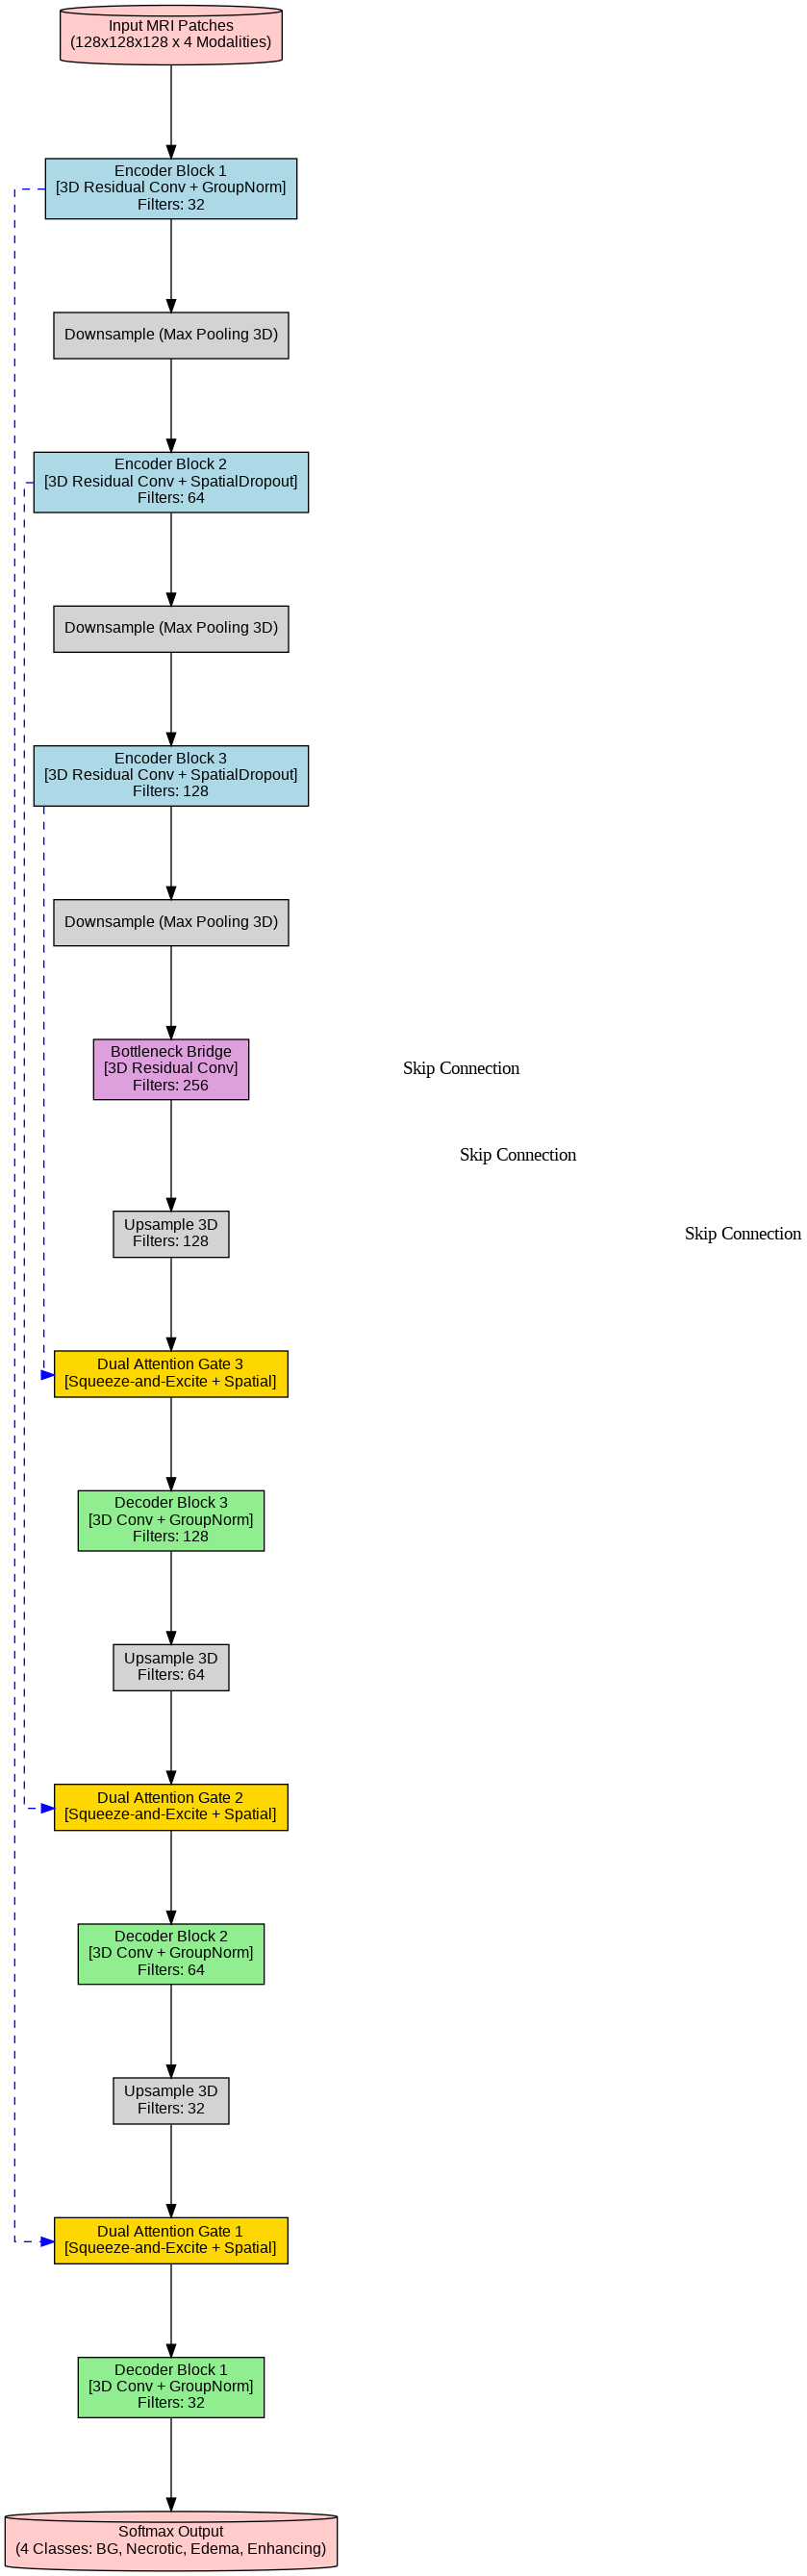

In [33]:
from graphviz import Digraph
from IPython.display import Image, display

def generate_architecture_diagram():
    # Initialize the graph
    dot = Digraph(format='png', graph_attr={'rankdir': 'TB', 'splines': 'ortho', 'nodesep': '0.8', 'ranksep': '1.0'})
    dot.attr('node', shape='box', style='filled', fontname='Helvetica', fontsize='12')

    # --- Colors ---
    c_inout = '#ffcccb'  # Light red
    c_enc = '#add8e6'    # Light blue
    c_dec = '#90ee90'    # Light green
    c_att = '#ffd700'    # Gold
    
    # --- Input ---
    dot.node('IN', 'Input MRI Patches\n(128x128x128 x 4 Modalities)', shape='cylinder', fillcolor=c_inout)

    # --- Encoder Path (Downsampling) ---
    dot.node('E1', 'Encoder Block 1\n[3D Residual Conv + GroupNorm]\nFilters: 32', fillcolor=c_enc)
    dot.node('P1', 'Downsample (Max Pooling 3D)', fillcolor='lightgrey')
    
    dot.node('E2', 'Encoder Block 2\n[3D Residual Conv + SpatialDropout]\nFilters: 64', fillcolor=c_enc)
    dot.node('P2', 'Downsample (Max Pooling 3D)', fillcolor='lightgrey')
    
    dot.node('E3', 'Encoder Block 3\n[3D Residual Conv + SpatialDropout]\nFilters: 128', fillcolor=c_enc)
    dot.node('P3', 'Downsample (Max Pooling 3D)', fillcolor='lightgrey')

    # --- Bottleneck ---
    dot.node('B', 'Bottleneck Bridge\n[3D Residual Conv]\nFilters: 256', fillcolor='#dda0dd') # Plum

    # --- Decoder Path (Upsampling + Attention) ---
    dot.node('UP3', 'Upsample 3D\nFilters: 128', fillcolor='lightgrey')
    dot.node('ATT3', 'Dual Attention Gate 3\n[Squeeze-and-Excite + Spatial]', fillcolor=c_att)
    dot.node('D3', 'Decoder Block 3\n[3D Conv + GroupNorm]\nFilters: 128', fillcolor=c_dec)

    dot.node('UP2', 'Upsample 3D\nFilters: 64', fillcolor='lightgrey')
    dot.node('ATT2', 'Dual Attention Gate 2\n[Squeeze-and-Excite + Spatial]', fillcolor=c_att)
    dot.node('D2', 'Decoder Block 2\n[3D Conv + GroupNorm]\nFilters: 64', fillcolor=c_dec)

    dot.node('UP1', 'Upsample 3D\nFilters: 32', fillcolor='lightgrey')
    dot.node('ATT1', 'Dual Attention Gate 1\n[Squeeze-and-Excite + Spatial]', fillcolor=c_att)
    dot.node('D1', 'Decoder Block 1\n[3D Conv + GroupNorm]\nFilters: 32', fillcolor=c_dec)

    # --- Output ---
    dot.node('OUT', 'Softmax Output\n(4 Classes: BG, Necrotic, Edema, Enhancing)', shape='cylinder', fillcolor=c_inout)

    # --- Standard Connections (Main Flow) ---
    dot.edges([('IN', 'E1'), ('E1', 'P1'), ('P1', 'E2'), ('E2', 'P2'), ('P2', 'E3'), ('E3', 'P3'), ('P3', 'B')])
    dot.edges([('B', 'UP3'), ('UP3', 'ATT3'), ('ATT3', 'D3')])
    dot.edges([('D3', 'UP2'), ('UP2', 'ATT2'), ('ATT2', 'D2')])
    dot.edges([('D2', 'UP1'), ('UP1', 'ATT1'), ('ATT1', 'D1')])
    dot.edges([('D1', 'OUT')])

    # --- Skip Connections (The "U" Shape) ---
    # We use constraint='false' so Graphviz draws them as horizontal bridges
    dot.edge('E3', 'ATT3', label=' Skip Connection', style='dashed', constraint='false', color='blue')
    dot.edge('E2', 'ATT2', label=' Skip Connection', style='dashed', constraint='false', color='blue')
    dot.edge('E1', 'ATT1', label=' Skip Connection', style='dashed', constraint='false', color='blue')

    # Save and display
    output_path = '/kaggle/working/custom_model_architecture'
    dot.render(output_path, cleanup=True)
    print(f"✅ Architecture diagram saved as {output_path}.png")
    
    return Image(f"{output_path}.png")

# Run the function
generate_architecture_diagram()

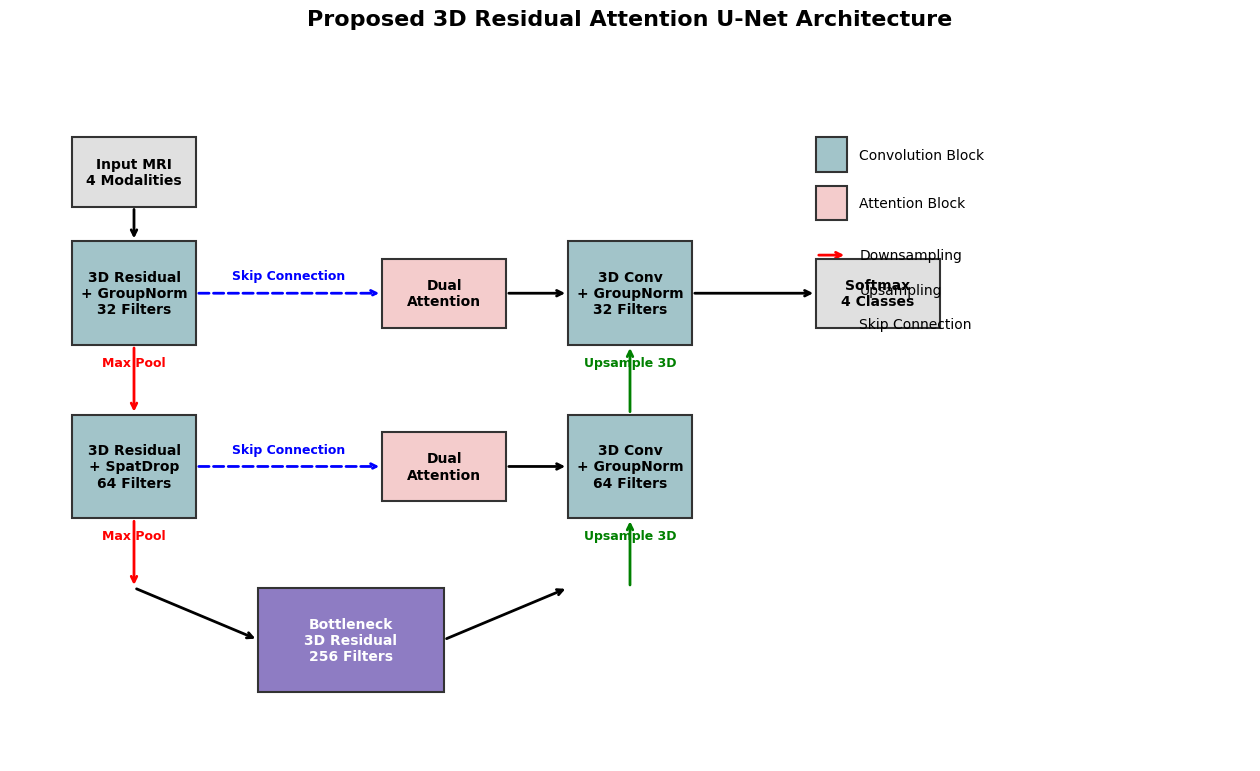

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_block(ax, x, y, width, height, color, text, text_color='black'):
    """Draws a styled neural network block"""
    box = patches.Rectangle((x, y), width, height, linewidth=1.5, edgecolor='#333333', facecolor=color, zorder=2)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, color=text_color, fontsize=10, 
            ha='center', va='center', fontweight='bold', zorder=3)

def draw_arrow(ax, x1, y1, x2, y2, style='-', color='black', label=''):
    """Draws a connecting arrow"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=2, ls=style), zorder=1)
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.2, label, fontsize=9, ha='center', color=color, fontweight='bold')

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 20)
ax.set_ylim(0, 10)
ax.axis('off')

# LATUP-inspired Color Palette
c_input = '#e0e0e0'  # Grey
c_conv = '#a2c4c9'   # Soft Blue
c_att = '#f4cccc'    # Soft Pink
c_bottle = '#8e7cc3' # Soft Purple

# --- Draw Encoder (Left Side) ---
draw_block(ax, 1, 8, 2, 1, c_input, "Input MRI\n4 Modalities")
draw_block(ax, 1, 6, 2, 1.5, c_conv, "3D Residual\n+ GroupNorm\n32 Filters")
draw_block(ax, 1, 3.5, 2, 1.5, c_conv, "3D Residual\n+ SpatDrop\n64 Filters")

# Downsampling Arrows
draw_arrow(ax, 2, 8, 2, 7.5)
draw_arrow(ax, 2, 6, 2, 5, color='red', label='Max Pool')
draw_arrow(ax, 2, 3.5, 2, 2.5, color='red', label='Max Pool')

# --- Bottleneck ---
# Correcting filters to 256
draw_block(ax, 4, 1, 3, 1.5, c_bottle, "Bottleneck\n3D Residual\n256 Filters", text_color='white')
draw_arrow(ax, 2, 2.5, 4, 1.75)
draw_arrow(ax, 7, 1.75, 9, 2.5)

# --- Attention & Decoder (Right Side) ---
# Level 2 (64 Filters)
draw_block(ax, 9, 3.5, 2, 1.5, c_conv, "3D Conv\n+ GroupNorm\n64 Filters")
draw_block(ax, 6, 3.75, 2, 1, c_att, "Dual\nAttention")
draw_arrow(ax, 3, 4.25, 6, 4.25, style='--', color='blue', label='Skip Connection')
draw_arrow(ax, 8, 4.25, 9, 4.25)

# Level 1 (32 Filters)
draw_block(ax, 9, 6, 2, 1.5, c_conv, "3D Conv\n+ GroupNorm\n32 Filters")
draw_block(ax, 6, 6.25, 2, 1, c_att, "Dual\nAttention")
draw_arrow(ax, 3, 6.75, 6, 6.75, style='--', color='blue', label='Skip Connection')
draw_arrow(ax, 8, 6.75, 9, 6.75)

# Upsampling Arrows
draw_arrow(ax, 10, 5, 10, 6, color='green', label='Upsample 3D')
draw_arrow(ax, 10, 2.5, 10, 3.5, color='green', label='Upsample 3D')

# Output
draw_block(ax, 13, 6.25, 2, 1, c_input, "Softmax\n4 Classes")
draw_arrow(ax, 11, 6.75, 13, 6.75)

# --- Legend (Like LATUP paper) ---
leg_y = 8.5
draw_block(ax, 13, leg_y, 0.5, 0.5, c_conv, "")
ax.text(13.7, leg_y+0.25, "Convolution Block", va='center')

draw_block(ax, 13, leg_y-0.7, 0.5, 0.5, c_att, "")
ax.text(13.7, leg_y-0.45, "Attention Block", va='center')

draw_arrow(ax, 13, leg_y-1.2, 13.5, leg_y-1.2, color='red')
ax.text(13.7, leg_y-1.2, "Downsampling", va='center')

draw_arrow(ax, 13, leg_y-1.7, 13.5, leg_y-1.7, color='green')
ax.text(13.7, leg_y-1.7, "Upsampling", va='center')

draw_arrow(ax, 13, leg_y-2.2, 13.5, leg_y-2.2, style='--', color='blue')
ax.text(13.7, leg_y-2.2, "Skip Connection", va='center')

plt.title("Proposed 3D Residual Attention U-Net Architecture", fontsize=16, fontweight='bold', y=1.05)
plt.savefig('/kaggle/working/professional_architecture.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
print(len(os.listdir("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")))

371


In [36]:
import os
import shutil
import numpy as np
import tensorflow as tf

# ==========================================
# 1. FILE TRANSFER (Kaggle Input -> Working)
# ==========================================

RAW_DATA = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

# VAL_DATA_PATH = '/kaggle/working/brats2020'


# # We use TrainingData for evaluation because ValidationData lacks ground truth masks
# if os.path.exists(RAW_DATA):
#     if os.path.exists(VAL_DATA_PATH): shutil.rmtree(VAL_DATA_PATH)
#     shutil.copytree(RAW_DATA, VAL_DATA_PATH)
#     print("✅ Evaluation data moved to /working")

# ==========================================
# 2. GENERATE VAL_IDS (Last 20% of Training)
# ==========================================
required_suffixes = ["_t1.nii", "_t1ce.nii", "_t2.nii", "_flair.nii", "_seg.nii"]

valid_cases = []
if os.path.exists(RAW_DATA):
    for patient in os.listdir(RAW_DATA):
        patient_path = os.path.join(RAW_DATA, patient)
        if not os.path.isdir(patient_path): continue
        files = os.listdir(patient_path)
        if all(any(f.endswith(suffix) for f in files) for suffix in required_suffixes):
            valid_cases.append(patient_path)

patients = sorted(valid_cases)
print(len(patients))
if patients:
    train_ids, val_ids = train_test_split(patients,test_size=0.2, random_state=42)
    print(f"Validation set ready with {len(val_ids)} patients.")

368
Validation set ready with 74 patients.


In [37]:
def load_patient(case_path):
    pid = os.path.basename(case_path)
    flair = nib.load(os.path.join(case_path, f"{pid}_flair.nii")).get_fdata()
    t1 = nib.load(os.path.join(case_path, f"{pid}_t1.nii")).get_fdata()
    t1ce = nib.load(os.path.join(case_path, f"{pid}_t1ce.nii")).get_fdata()
    t2 = nib.load(os.path.join(case_path, f"{pid}_t2.nii")).get_fdata()
    seg = nib.load(os.path.join(case_path, f"{pid}_seg.nii")).get_fdata()
    seg[seg == 4] = 3 
    return np.stack([flair, t1, t1ce, t2], axis=-1), seg

def crop_brain_roi(volume, mask):
    brain = volume[..., 0] > 0
    coords = np.argwhere(brain)
    if len(coords) == 0: return volume, mask
    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0)
    return volume[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1], mask[zmin:zmax+1, ymin:ymax+1, xmin:xmax+1]

def normalize_mri(volume):
    brain_mask = volume > 0
    normalized = np.zeros_like(volume, dtype=np.float32)
    for i in range(volume.shape[-1]):
        channel = volume[..., i]
        mask = brain_mask[..., i]
        if mask.any():
            mean, std = channel[mask].mean(), channel[mask].std()
            normalized[..., i] = (channel - mean) / (std + 1e-8) 
    return normalized

In [38]:

# ==========================================
# 3. LOAD MODEL & COMPUTE METRICS
# ==========================================
print("\nLoading Best Model for Final Evaluation...")

# Strategy scope ensures the custom layers (Attention, Residual) 
# are distributed correctly across the Kaggle GPU
with strategy.scope():
    # Rebuild your specific 3D architecture
    final_model = build_model() 
    
    # Load your custom weights directly into the layers
    final_model.load_weights(BEST_MODEL_PATH)
    print("✅ Model weights loaded successfully!\n")

wt_scores, tc_scores, et_scores = [], [], []

print(f"Starting inference on all {len(val_ids)} validation patients...\n")

for i, pid in enumerate(val_ids):
    # predict_patient must handle loading, cropping, and sliding window inference
    pred, gt = predict_patient(pid, final_model)
    
    # BraTS Clinical Region Mapping:
    # WT (Whole Tumor): Necrotic (1) + Edema (2) + Enhancing (3)
    # TC (Tumor Core): Necrotic (1) + Enhancing (3)
    # ET (Enhancing Tumor): Enhancing (3)
    wt_scores.append(brats_dice(pred, gt, [1, 2, 3]))
    tc_scores.append(brats_dice(pred, gt, [1, 3]))
    et_scores.append(brats_dice(pred, gt, [3]))
    
    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(val_ids)} | Avg WT: {np.mean(wt_scores):.4f} | TC: {np.mean(tc_scores):.4f} | ET: {np.mean(et_scores):.4f}")

# ==========================================
# 4. FINAL OUTPUT SUMMARY
# ==========================================
print("\n" + "="*40 + "\nFINAL CLINICAL VALIDATION SCORES\n" + "="*40)
print(f"Mean Whole Tumor (WT) Dice:      {np.mean(wt_scores):.4f}")
print(f"Mean Tumor Core (TC) Dice:       {np.mean(tc_scores):.4f}")
print(f"Mean Enhancing Tumor (ET) Dice:  {np.mean(et_scores):.4f}")
print("="*40)


Loading Best Model for Final Evaluation...
✅ Model weights loaded successfully!

Starting inference on all 74 validation patients...

Processed 10/74 | Avg WT: 0.9184 | TC: 0.8948 | ET: 0.7821
Processed 20/74 | Avg WT: 0.9219 | TC: 0.8718 | ET: 0.7815
Processed 30/74 | Avg WT: 0.9193 | TC: 0.8644 | ET: 0.7660
Processed 40/74 | Avg WT: 0.9177 | TC: 0.8701 | ET: 0.7421
Processed 50/74 | Avg WT: 0.9104 | TC: 0.8755 | ET: 0.7416
Processed 60/74 | Avg WT: 0.9054 | TC: 0.8669 | ET: 0.7362
Processed 70/74 | Avg WT: 0.9055 | TC: 0.8572 | ET: 0.7355

FINAL CLINICAL VALIDATION SCORES
Mean Whole Tumor (WT) Dice:      0.9057
Mean Tumor Core (TC) Dice:       0.8485
Mean Enhancing Tumor (ET) Dice:  0.7290
